# Индивидуальная работа  №2

## Тема работы: Продвинутый статистический анализ данных и методы машинного обучения
## Объект исследования: Рынок недвижимости в Индии

**Авторы работы:** Калинкова София, Павлышина Александра, Жантуан Анастасия

**группа:** I2302

**Dataset:** House Price  https://www.kaggle.com/datasets/juhibhojani/house-price

## I Введение

#### 1.1 Описание исследуемой проблемы
Рынок недвижимости является одним из самых сложных и динамичных секторов экономики. Стоимость объекта жилья не определяется одним фактором; она представляет собой многомерную зависимость от физических характеристик, местоположения и качественных параметров.

Покупатели и инвесторы сталкиваются с проблемой:

- как определить, справедлива ли цена недвижимости
- какие характеристики наиболее сильно влияют на стоимость
- как сравнивать объекты между собой

#### 1.2 Обоснование актуальности темы

Анализ недвижимости играет важную роль в банковской сфере (ипотечное кредитование), инвестиционной деятельности и городском планировании, что делает данную тему актуальной и практически значимой.

Использование методов машинного обучения и статистики позволяет повысить точность оценки, выявить скрытые зависимости между характеристиками объектов и их стоимостью, а также принимать более обоснованные решения.

#### 1.3 Цели анализа

1. Провести комплексный статистический анализ факторов, влияющих на стоимость жилья.
2. Разработать прогностическую модель для предсказания цены.
3. Применить метод главных компонент (PCA) для выявления скрытых структур в характеристиках домов и оптимизации количества признаков.
4. Интерпретировать полученные результаты для формирования практических рекомендаций.

#### 1.4. Описание датасета

- Название: **House Price Dataset**
- Источник: **Kaggle**
- Количество наблюдений: **187 531** записей (объектов недвижимости)
- Количество переменных: **21**

Датасет сформирован на основе данных, собранных методом веб-скрейпинга с сайтов недвижимости.

##### Числовые переменные

(после предварительной обработки)

* Price (in rupees) — цена за единицу площади
* Bathroom — количество ванных комнат
* Balcony — количество балконов
* Carpet Area — жилая площадь
* Super Area — общая площадь
* Floor — этаж

##### Категориальные переменные

* location — местоположение объекта
* Status — статус объекта (готов / строится)
* Transaction — тип жилья
* Furnishing — уровень мебелировки
* facing — направление объекта
* overlooking — вид из объекта
* Society — название жилого комплекса
* Ownership — форма собственности
* Car Parking — наличие или тип паркинга(крытый/ на открытом воздухе)


##### Текстовые переменные

* Title — заголовок объявления
* Description — описание объекта
* Amount (in rupees) — общая цена 

## II Обработка и очистка данных

#### 2.1 Начальная обработка данных



In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df_raw = pd.read_csv('house_prices.csv')

print("Размер датасета:", df_raw.shape)

df_raw.head()

Размер датасета: (158083, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti Siddhi Mangal Murti Complex Bhiwandi,"Bhiwandi, Thane has an attractive 1 BHK Flat for sale. The property is ideally located in a strategic location in Srushti Siddhi Mangal Murti Complex township. This flat for resale is a choice property. This apartment ready to move in the Bhiwandi is available for an attractive price of INR 42 Lac. You will find it unfurnished.",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti Vihar Pokhran Road,"One can find this stunning 2 BHK flat for sale in Pokhran Road, Thane. It enjoys an excellent location within the Dosti Vihar. This flat for resale is a choice property. This ready to move flat in Pokhran Road can be availed at a reasonable price of INR 98 Lac. This semi-furnished flat is strategically designed with all the amenities to enhance the living experience. The property is strategically placed near prominent places as near singhaniya school which make for the smooth living of residents.",98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise by Kalpataru Kolshet Road,"Up for immediate sale is a 2 BHK apartment in Kolshet Road, Thane. Don't miss this bargain flat for sale. Situated in the Sunrise By Kalpataru township, it has a prime location. This flat for resale has a desirable location. You can buy this ready to move flat in Kolshet Road at a reasonable price of INR 1.40 Cr. This unfurnished flat is strategically designed with all the amenities to enhance the living experience. Landmarks near the apartment include pokhran road no 2.",1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,"This beautiful 1 BHK Flat is available for sale in Kasheli, Thane. This flat for resale has a desirable location. This ready to move flat is offered at an economical price of INR 25 Lac. You will find it unfurnished.",25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Habitat Raymond Realty Pokhran Road,"This lovely 2 BHK Flat in Pokhran Road, Thane is up for sale. This flat is situated in the Tenx Habitat Raymond Realty township and is equipped with premium facilities. This flat is an attractive property for resale. You can buy this ready to move flat in Pokhran Road at a reasonable price of INR 1.60 Cr. You will find it unfurnished. Some of the landmarks in the vicinity include pokhran road 2.",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


Первичный просмотр первых строк позволяет ознакомиться со структурой данных.
Датасет содержит 187531 наблюдений и 21 переменных. 

#### 2.2 Работа с пропущенными значениями


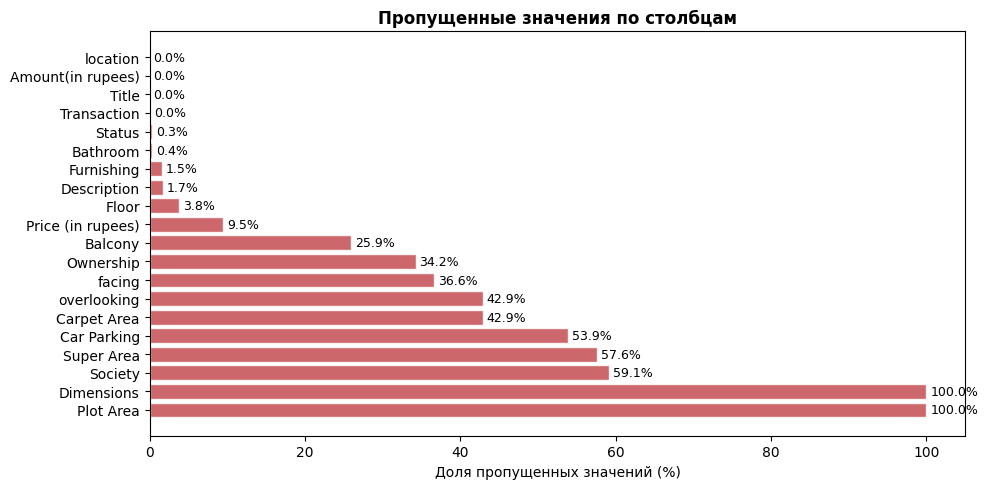

In [47]:
miss_data = df_raw.isnull().mean().sort_values(ascending=False) * 100
miss_data = miss_data[miss_data > 0]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(miss_data.index, miss_data.values, color='#C44E52', alpha=0.85, edgecolor='white')
ax.set_xlabel('Доля пропущенных значений (%)')
ax.set_title('Пропущенные значения по столбцам', fontweight='bold')
for bar, val in zip(bars, miss_data.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_missing.png', bbox_inches='tight')
plt.show()

Было принято решение удалить записи где есть пустые значения для большего реализма данных.

In [48]:
df = df_raw.copy()

cols_to_drop = ['Index', 'Title', 'Description', 'Plot Area', 'Dimensions', 'Society', 'Super Area', 'Car Parking']

df = df.drop(columns=cols_to_drop, errors='ignore')

# копия исходного датасета
df_dropna = df.copy()

# исключаем столбцы, которые не учитываем
cols_to_ignore = ['Dimensions', 'Plot Area']

# берём только нужные столбцы
cols_to_check = [col for col in df_dropna.columns if col not in cols_to_ignore]

# удаляем строки с пропусками
df_dropna = df_dropna.dropna(subset=cols_to_check)

print("Размер исходного датасета:", df.shape)
print("Размер после удаления строк с пропусками:", df_dropna.shape)

Размер исходного датасета: (158083, 13)
Размер после удаления строк с пропусками: (55195, 13)


Заметим что записей стало почти в 3 раза меньше (64 тыс)

## 2. Приводим "числовые строки" к числам

Так как некоторые текстовые переменные содержать числа с которыми нам надо работать, мы их преобразуем в числа 

Столбец: **Carpet Area**  ['500 sqft', '473 sqft', '779 sqft', '530 sqft', '635 sqft']

Столбец: **Floor** ['10 out of 11', '3 out of 22', '10 out of 29', '1 out of 3', '20 out of 42']

### Преобразование переменных к числовому виду

Для приведения данных к удобному для анализа виду были выполнены следующие преобразования:

- переменные `Bathroom` и `Balcony` ('2') переведены в числовой формат; 
- из переменной `Carpet Area` ('500 sqft') извлечено числовое значение площади;
- переменная `Floor` ('3 out of 22') разделена на два признака:
    - этаж квартиры (Floor_Number);
    - общее количество этажей в здании (Total_Floors);

In [49]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

df_clean = df_dropna.copy()

if 'Bathroom' in df_clean.columns:
    df_clean['Bathroom'] = pd.to_numeric(df_clean['Bathroom'], errors='coerce')

if 'Balcony' in df_clean.columns:
    df_clean['Balcony'] = pd.to_numeric(df_clean['Balcony'], errors='coerce')

if 'Carpet Area' in df_clean.columns:
    df_clean['Carpet Area'] = (
        df_clean['Carpet Area']
        .astype(str)
        .str.extract(r'(\d+\.?\d*)')[0]
    )
    df_clean['Carpet Area'] = pd.to_numeric(df_clean['Carpet Area'], errors='coerce')

if 'Price (in rupees)' in df_clean.columns:
    df_clean['Price (in rupees)'] = pd.to_numeric(
        df_clean['Price (in rupees)'], errors='coerce'
    )

if 'Floor' in df_clean.columns:
    df_clean['Floor'] = df_clean['Floor'].astype(str)

    df_clean['Floor'] = df_clean['Floor'].str.replace('Ground', '0', regex=False)
    df_clean['Floor'] = df_clean['Floor'].str.replace('Lower Basement', '-1', regex=False)
    df_clean['Floor'] = df_clean['Floor'].str.replace('Upper Basement', '-1', regex=False)

    floor_split = df_clean['Floor'].str.extract(r'(-?\d+)\s*out of\s*(\d+)')
    df_clean['Floor_Number'] = pd.to_numeric(floor_split[0], errors='coerce')
    df_clean['Total_Floors'] = pd.to_numeric(floor_split[1], errors='coerce')

needed_cols = [
    'Price (in rupees)',
    'Carpet Area',
    'Bathroom',
    'Balcony',
    'Floor_Number',
    'Total_Floors'
]
needed_cols = [col for col in needed_cols if col in df_clean.columns]

df_clean = df_clean.dropna(subset=needed_cols)

display(df_clean[needed_cols].head())
print("Размер после преобразований:", df_clean.shape)

,Price (in rupees),Carpet Area,Bathroom,Balcony,Floor_Number,Total_Floors
9,11150.0,900,3.0,1.0,3,27
13,17526.0,1820,4.0,1.0,18,27
15,10000.0,675,2.0,1.0,10,16
16,5736.0,647,1.0,2.0,5,7
21,15000.0,665,2.0,2.0,15,31


Размер после преобразований: (55193, 15)


### Выявление и обработка выбросов 
Выбросы могут существенно искажать результаты статистического анализа, поэтому их выявление и обработка являются важным этапом предобработки данных.

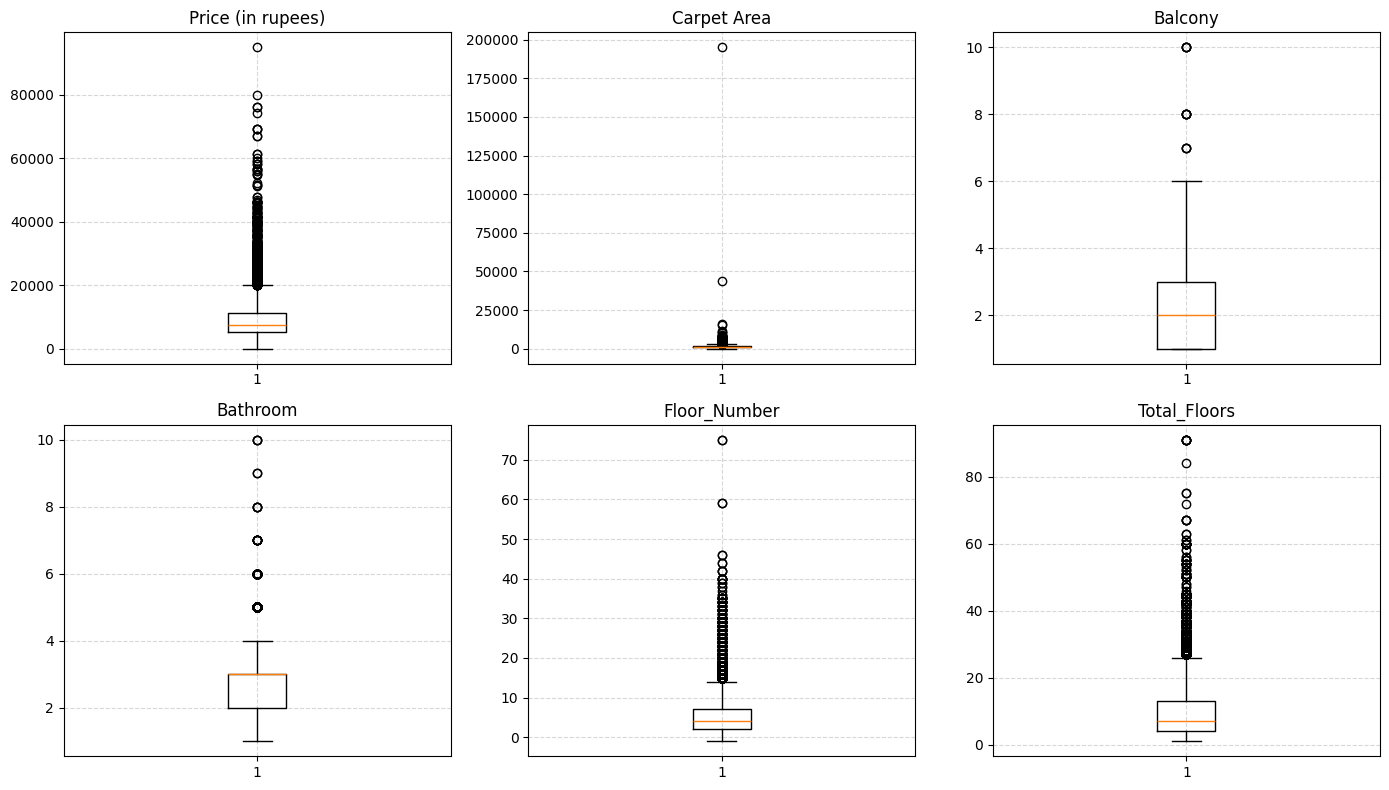

In [50]:
cols = ['Price (in rupees)', 'Carpet Area', 'Balcony', 'Bathroom', 'Floor_Number', 'Total_Floors']

plt.figure(figsize=(14, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df_clean[col])
    plt.title(col)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Видно, что во всех переменных есть выделяющиеся значения, скорее всего ошибочные:

**1. `Carpet Area`** Есть очень большие значения — сотни тысяч sqft. 

**3. `Price (in rupees)`** Цена тоже имеет очень длинный хвост. 

**4. `Balcony` и `Bathroom`**
* `Bathroom = 10` — может встретиться у очень большого дома, но для основной массы объектов это уже крайность.
* `Balcony = 10` — тоже очень нетипично.

Поэтому немного уменьшим диапазоны чисел чтобы приблизить их к более реальным значением.

In [51]:
df_final = df_clean.copy()

df_final = df_final[
    (df_final['Price (in rupees)'] > 0) &
    (df_final['Price (in rupees)'] <= 100000) &

    (df_final['Carpet Area'] > 0) &
    (df_final['Carpet Area'] <= 10000) &

    (df_final['Bathroom'] >= 1) &
    (df_final['Bathroom'] <= 6) &

    (df_final['Balcony'] >= 0) &
    (df_final['Balcony'] <= 6) &

    (df_final['Floor_Number'] >= 0) &
    (df_final['Floor_Number'] <= 75) &

    (df_final['Total_Floors'] >= 1) &
    (df_final['Total_Floors'] <= 75)
]

print("До очистки:", df_clean.shape)
print("После очистки:", df_final.shape)

До очистки: (55193, 15)
После очистки: (55063, 15)


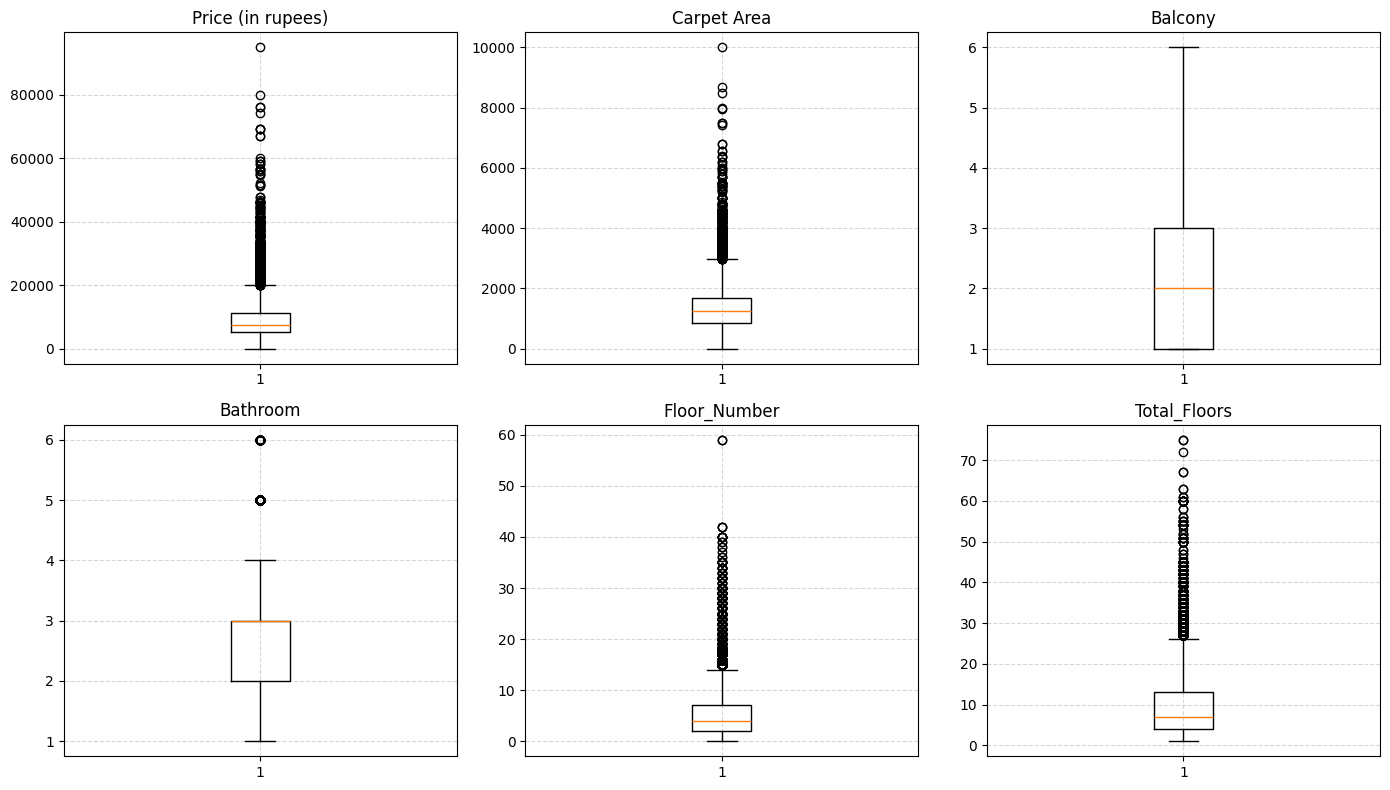

In [52]:
cols = ['Price (in rupees)', 'Carpet Area', 'Balcony', 'Bathroom', 'Floor_Number', 'Total_Floors']

plt.figure(figsize=(14, 8))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df_final[col])
    plt.title(col)
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Кодирование категориальных переменных

Для каждой категориальной переменной было проанализировано количество уникальных значений:


In [53]:
cat_cols = df_final.select_dtypes(include=['object', 'string']).columns
cat_cols = cat_cols.drop(['Amount(in rupees)', 'Floor'], errors='ignore')

for col in cat_cols:
    print(f'\n{col}:')
    print("Уникальных значений:", df_final[col].nunique())


location:
Уникальных значений: 32

Status:
Уникальных значений: 1

Transaction:
Уникальных значений: 2

Furnishing:
Уникальных значений: 3

facing:
Уникальных значений: 8

overlooking:
Уникальных значений: 16

Ownership:
Уникальных значений: 4


In [54]:
df_model = df_final.drop(
    columns=['Amount(in rupees)', 'location', 'Status', 'overlooking', 'Floor'],
    errors='ignore'
)

cat_cols = ['Transaction', 'Furnishing', 'facing', 'Ownership']

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

bool_cols = df_model.select_dtypes(include=['bool']).columns
df_model[bool_cols] = df_model[bool_cols].astype(int)

print(df_model.shape)
df_model.head()

(55063, 19)


,Price (in rupees),Carpet Area,Bathroom,Balcony,Floor_Number,Total_Floors,Transaction_Resale,Furnishing_Semi-Furnished,Furnishing_Unfurnished,facing_North,facing_North - East,facing_North - West,facing_South,facing_South - East,facing_South -West,facing_West,Ownership_Freehold,Ownership_Leasehold,Ownership_Power Of Attorney
9,11150.0,900,3.0,1.0,3,27,1,0,1,0,0,0,0,0,0,0,1,0,0
13,17526.0,1820,4.0,1.0,18,27,1,1,0,0,0,0,0,0,0,0,1,0,0
15,10000.0,675,2.0,1.0,10,16,0,0,1,0,1,0,0,0,0,0,1,0,0
16,5736.0,647,1.0,2.0,5,7,0,0,1,0,0,0,0,0,0,0,1,0,0
21,15000.0,665,2.0,2.0,15,31,1,0,1,0,0,0,0,0,0,0,1,0,0


Для оставшихся категориальных переменных (Transaction, Furnishing, facing, Ownership) был применён **метод one-hot encoding**. В результате каждая категория была преобразована в отдельный бинарный признак.

При кодировании использовался **параметр drop_first=True**, что позволило избежать избыточности признаков и снизить риск мультиколлинеарности в модели.

В результате преобразований итоговый датасет содержит 64321 наблюдение и 19 признаков, все из которых представлены в числовом формате и готовы к дальнейшему анализу и построению модели.

---
## III. Анализ данных и продвинутые визуализации

Раздел посвящён исследовательскому анализу данных с целью выявления основных закономерностей, распределений и взаимосвязей между признаками

### 3.1 Описательные статистики числовых переменных

Для числовых признаков были рассчитаны основные описательные статистики: среднее значение, стандартное отклонение, минимум, максимум, квартили, коэффициент вариации и асимметрия.

In [55]:
numeric_cols = ['Price (in rupees)', 'Carpet Area', 'Bathroom', 'Balcony',
               'Floor_Number', 'Total_Floors']

desc = df_final[numeric_cols].describe().T
desc['CV (%)'] = (desc['std'] / desc['mean'] * 100).round(1)
desc['skewness'] = df_final[numeric_cols].skew().values
desc = desc.round(2)
desc

,count,mean,std,min,25%,50%,75%,max,CV (%),skewness
Price (in rupees),55063.0,8791.86,4864.41,1.0,5176.5,7500.0,11167.0,95000.0,55.3,2.26
Carpet Area,55063.0,1307.80,789.94,2.0,850.0,1250.0,1700.0,10000.0,60.4,1.49
Bathroom,55063.0,2.73,0.92,1.0,2.0,3.0,3.0,6.0,33.6,0.44
Balcony,55063.0,2.19,0.98,1.0,1.0,2.0,3.0,6.0,44.9,0.57
Floor_Number,55063.0,5.20,4.58,0.0,2.0,4.0,7.0,59.0,88.1,1.67
Total_Floors,55063.0,9.68,7.77,1.0,4.0,7.0,13.0,75.0,80.2,1.54


**Интерпретация:**  
Цены сильно различаются — есть дешёвые квартиры и немного очень дорогих. Площадь тоже распределена неравномерно: большинство квартир небольшие.

### 3.2 Распределение числовых переменных

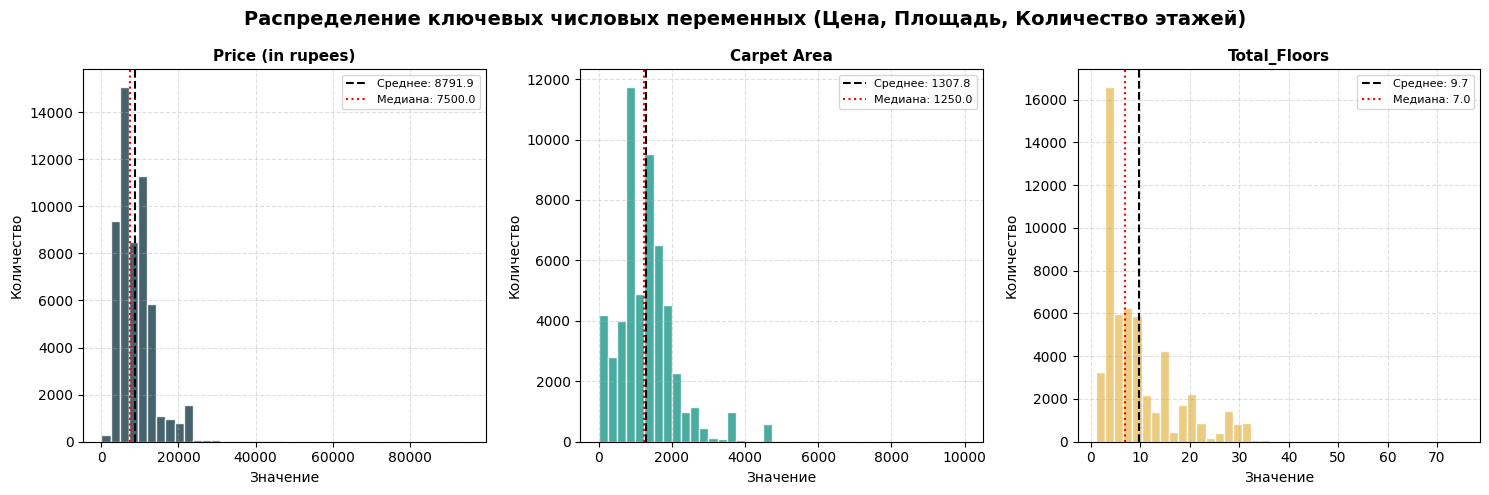

In [56]:
numeric_cols_plot = ['Price (in rupees)', 'Carpet Area', 'Total_Floors']
numeric_cols_plot = [c for c in numeric_cols_plot if c in df_final.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#264653', '#2a9d8f', '#e9c46a']

for ax, col, c in zip(axes.flatten(), numeric_cols_plot, colors):
    data = df_final[col].dropna()
    
    ax.hist(data, bins=40, color=c, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Среднее: {data.mean():.1f}')
    ax.axvline(data.median(), color='red', linestyle=':', linewidth=1.5,
               label=f'Медиана: {data.median():.1f}')
    
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Значение')
    ax.set_ylabel('Количество')
    ax.legend(fontsize=8)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Распределение ключевых числовых переменных (Цена, Площадь, Количество этажей)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Интерпретация:**  
**Цена (Price):** Большинство квартир стоит относительно недорого, а очень дорогих — мало. Из-за этого среднее выше медианы → есть выбросы (дорогие объекты).  
**Площадь (Carpet Area):** Чаще всего встречаются квартиры средней площади (примерно до 1500). Большие квартиры есть, но их немного.  
**Количество этажей (Total Floors):** В основном дома невысокие (до ~10 этажей). Высокие здания встречаются реже.  

### 3.3 Распределение категориальных переменных

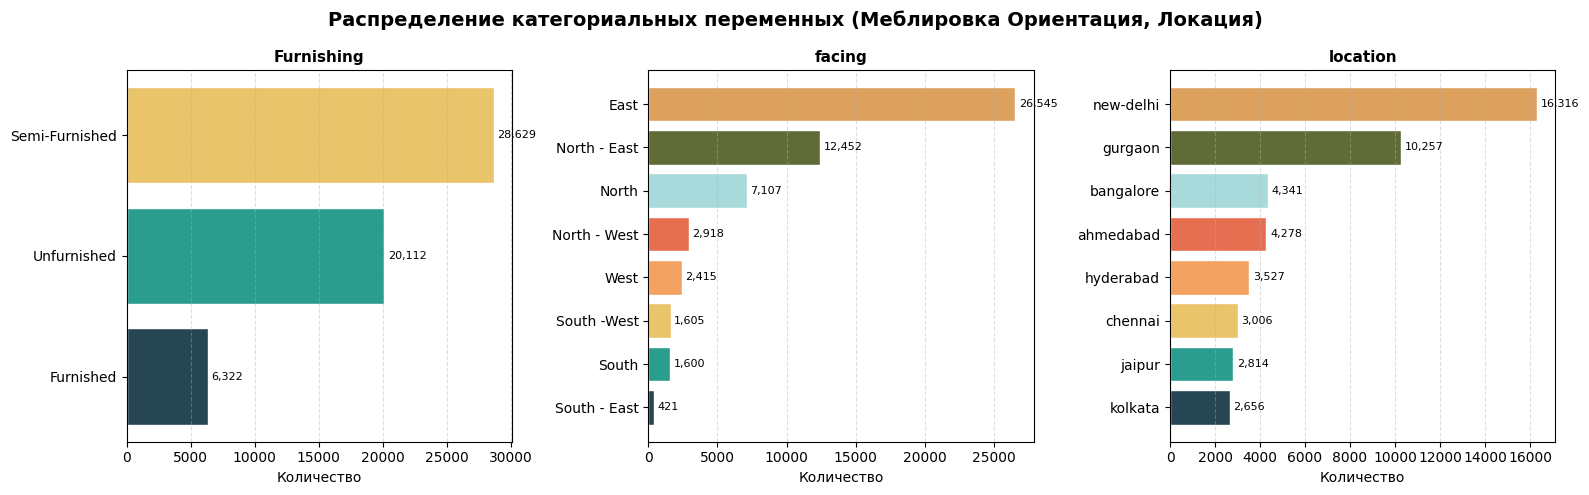

In [57]:
cat_cols_plot = ['Furnishing', 'facing', 'location']
cat_cols_plot = [c for c in cat_cols_plot if c in df_final.columns]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = ['#264653', '#2a9d8f', '#e9c46a', '#f4a261', '#e76f51', '#a8dadc',
           '#606c38', '#dda15e', '#bc6c25', '#cdb4db']

for ax, col in zip(axes.flatten(), cat_cols_plot):
    vc = df_final[col].value_counts().head(8)
    bars = ax.barh(vc.index[::-1], vc.values[::-1],
                   color=palette[:len(vc)], edgecolor='white')
    
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Количество')
    ax.grid(True, axis='x', linestyle='--', alpha=0.4)
    
    for bar, val in zip(bars, vc.values[::-1]):
        ax.text(bar.get_width() + vc.max() * 0.01,
                bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)

plt.suptitle('Распределение категориальных переменных (Меблировка Ориентация, Локация)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Интерпретация:**  
**Меблировка (Furnishing):** Чаще всего квартиры с частичной мебелью (Semi-Furnished) или без мебели. Полностью меблированных объектов намного меньше.  
**Ориентация (facing):** Самые популярные направления — East и North-East. Остальные встречаются значительно реже.  
**Локация (location):** Больше всего объектов в New Delhi и Gurgaon. Другие города представлены заметно меньше.

### 3.4 Корреляционная матрица числовых переменных (Heatmap)

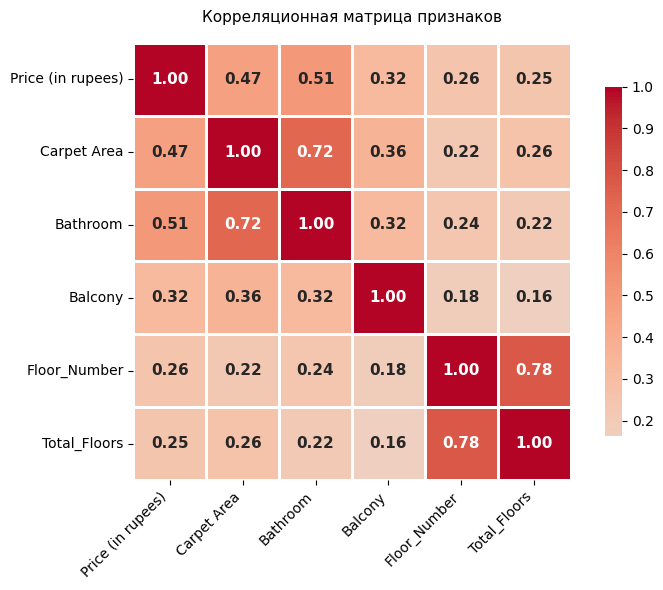

In [58]:
corr_matrix = df_final[numeric_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.8,
    linecolor='white',
    cbar_kws={'shrink': 0.8},
    annot_kws={'size': 11, 'weight': 'bold'}
)

plt.title('Корреляционная матрица признаков',
          fontsize=11, pad=15)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**Интерпретация:**  
Цена сильнее всего связана с площадью (0.45) и количеством ванных (0.49) - чем больше квартира, тем она дороже. Связь цены с балконами и этажами слабая - они почти не влияют. Площадь и ванные сильно связаны (0.71) - большие квартиры обычно имеют больше ванных комнат. Этаж и общее число этажей сильно связаны (0.77) - это естественно, так как эти признаки связаны между собой.

### 3.5 Цена в зависимости от категориальных переменных (условные распределения)

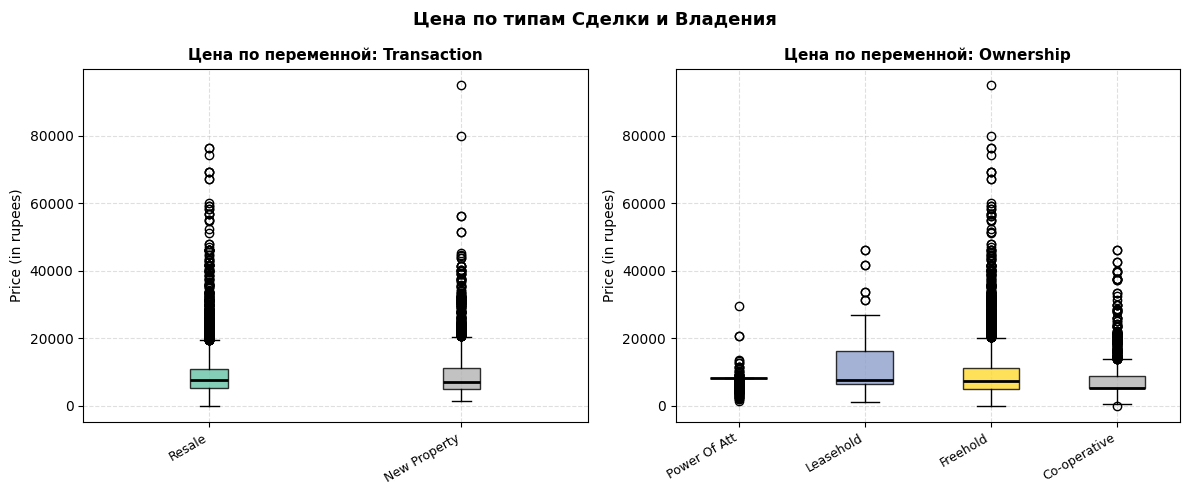

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cat_vars = ['Transaction', 'Ownership']
cat_vars = [c for c in cat_vars if c in df_final.columns]

for ax, col in zip(axes.flatten(), cat_vars):
    order = df_final.groupby(col)['Price (in rupees)'].median()\
                    .sort_values(ascending=False).index
    
    df_plot = df_final[[col, 'Price (in rupees)']].dropna()
    groups = [df_plot[df_plot[col] == cat]['Price (in rupees)'].values
              for cat in order]

    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    
    colors_box = plt.cm.Set2(np.linspace(0, 1, len(order)))
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)

    ax.set_xticklabels([o[:12] for o in order],
                       rotation=30, ha='right', fontsize=9)
    ax.set_title(f'Цена по переменной: {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (in rupees)')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Цена по типам Сделки и Владения',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Интерпретация:**  
**Transaction (тип сделки):** Цены у Resale и New Property примерно одинаковые. Тип сделки почти не влияет на стоимость.  
**Ownership (тип владения):** Freehold в среднем немного дороже других вариантов. Leasehold, Co-operative и Power of Attorney имеют более низкие и похожие цены.  
На всех графиках видно много выбросов — есть отдельные очень дорогие квартиры.

### 3.6 Медианная цена по локациям (топ-15)

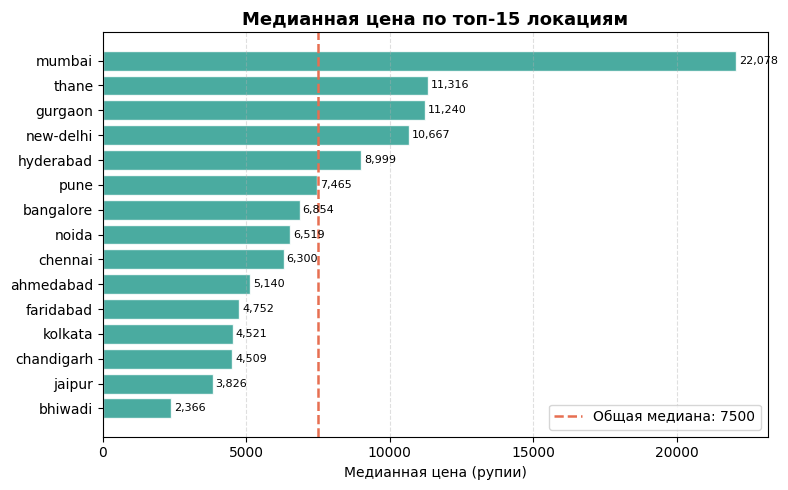

In [60]:
top_locs = df_final['location'].value_counts().head(15).index
df_top = df_final[df_final['location'].isin(top_locs)]

loc_stats = df_top.groupby('location')['Price (in rupees)'].agg(
    ['median', 'mean', 'count']).reset_index()
loc_stats = loc_stats.sort_values('median', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(loc_stats['location'], loc_stats['median'],
               color='#2a9d8f', edgecolor='white', alpha=0.85)
overall_median = df_final['Price (in rupees)'].median()
ax.axvline(overall_median, color='#e76f51', linestyle='--', linewidth=1.8,
           label=f'Общая медиана: {overall_median:.0f}')
for bar, val in zip(bars, loc_stats['median']):
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8)
ax.set_title('Медианная цена по топ-15 локациям', fontsize=13, fontweight='bold')
ax.set_xlabel('Медианная цена (рупии)')
ax.legend()
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Интерпретация:**  
Цены на квартиры сильно отличаются в зависимости от города. Самые дорогие локации — Thane, Gurgaon и New Delhi. Самые дешёвые — Jaipur, Zirakpur и Chandigarh. Часть городов имеет цены выше общей медианы, а часть — ниже.

### 3.7 Тепловая карта: медианная цена по этажу и числу ванных

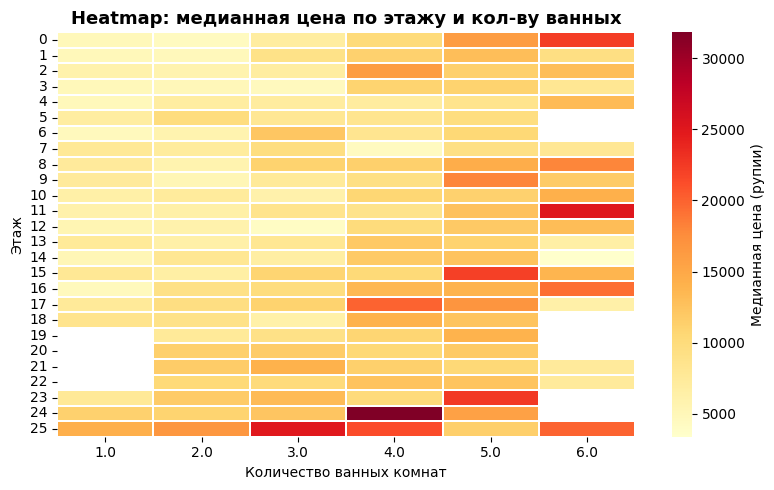

In [61]:
pivot = df_final.groupby(['Floor_Number', 'Bathroom'])['Price (in rupees)'].median().unstack()
pivot = pivot.loc[pivot.index <= 25, :].dropna(how='all')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=False, cmap='YlOrRd', linewidths=0.3,
            cbar_kws={'label': 'Медианная цена (рупии)'}, ax=ax)
ax.set_title('Heatmap: медианная цена по этажу и кол-ву ванных',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Количество ванных комнат')
ax.set_ylabel('Этаж')
plt.tight_layout()
plt.show()

**Интерпретация:**  
Цена растёт с увеличением количества ванных комнат — чем их больше, тем дороже квартира. Также видно, что более высокие этажи часто имеют более высокие цены, но эта зависимость слабее. Самые дорогие квартиры — это обычно объекты с 4–6 ванными и на средних или высоких этажах.

## IV. Модели регрессии и классификации



### 4.1. Простая линейная регрессия

Для первоначального анализа зависимости между ценой недвижимости и ее характеристиками была построена модель простой линейной регрессии.
В качестве независимой переменной был выбран признак **Carpet Area**, а в качестве зависимой переменной — **Price (in rupees)**.

Для обучения модели данные были разделены на обучающую и тестовую выборки в соотношении 80% к 20%.


In [62]:
# 1. Выбираем признак и целевую переменную
X = df_model[['Carpet Area']]
y = df_model['Price (in rupees)']

# 2. Делим на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Обучаем модель
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Делаем прогноз
y_pred = model.predict(X_test)

# 5. Метрики
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Коэффициент (beta1):", model.coef_[0])
print("Свободный член (beta0):", model.intercept_)
print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

Коэффициент (beta1): 2.8683890406986112
Свободный член (beta0): 5038.087972946818
R²: 0.22444655107278344
MAE: 2905.375396054692
RMSE: 4399.002770207595


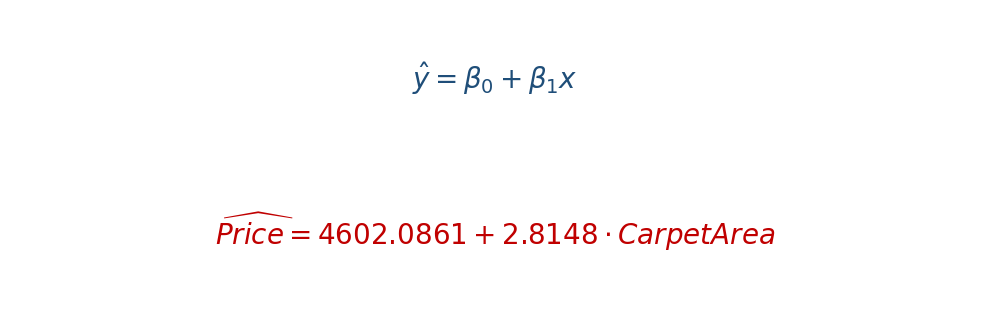

In [63]:
b0 = 4602.0861
b1 = 2.8148

fig, axes = plt.subplots(2, 1, figsize=(10, 3.2))
fig.patch.set_alpha(0)

for ax in axes:
    ax.axis('off')
    ax.set_facecolor('none')

axes[0].text(0.5, 0.5, r'$\hat{y} = \beta_0 + \beta_1 x$', fontsize=20, ha='center', va='center', color='#1F4E79')
axes[1].text(0.5, 0.5, fr'$\widehat{{Price}} = {b0:.4f} + {b1:.4f} \cdot CarpetArea$', fontsize=20, ha='center', va='center', color='#C00000')

plt.tight_layout()
plt.show()



### Интерпретация коэффициентов

Полученное уравнение показывает, что при увеличении значения **Carpet Area** на 1 единицу прогнозируемая цена недвижимости в среднем увеличивается на **2.81** единицы, при прочих равных условиях.

Свободный член $\beta_0$ показывает теоретическое значение цены при нулевой площади, однако в практическом смысле этот показатель не имеет самостоятельной экономической интерпретации и служит частью уравнения регрессии.

### Оценка качества модели

Значение коэффициента детерминации **(R^2 = 0.20)** показывает, что модель объясняет около **20% вариации цены** только за счет признака **Carpet Area**. Это говорит о том, что площадь действительно влияет на стоимость недвижимости, однако сама по себе не способна достаточно точно объяснить цену объекта.

Значения **MAE** и **RMSE** также указывают на наличие заметных ошибок прогноза. Следовательно, для более точного моделирования необходимо учитывать не один, а несколько признаков одновременно.

### Визуализация простой линейной регрессии

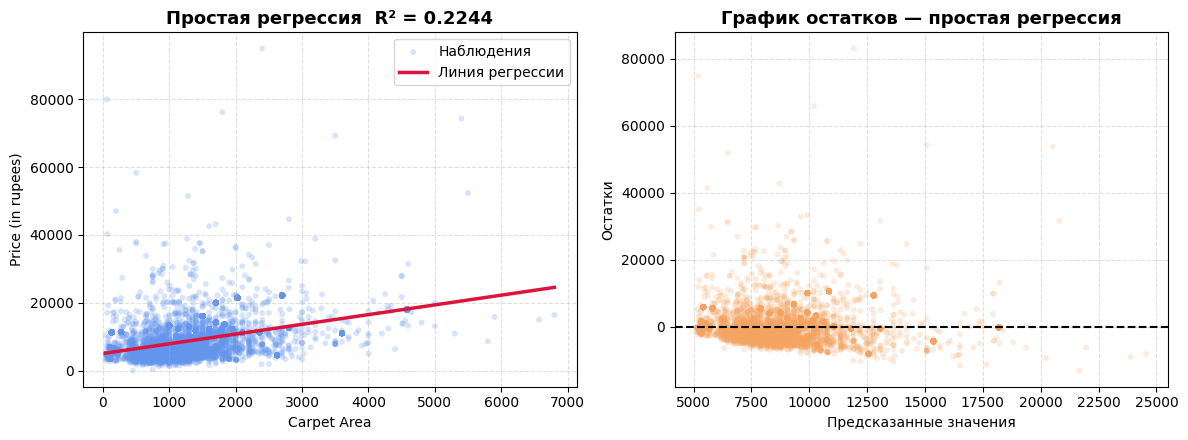

In [64]:
residuals = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].scatter(X_test['Carpet Area'], y_test, alpha=0.25, s=18, color='cornflowerblue', edgecolor='none', label='Наблюдения')

x_line = np.linspace(X_test['Carpet Area'].min(), X_test['Carpet Area'].max(), 200).reshape(-1, 1)
y_line = model.predict(x_line)

axes[0].plot(x_line, y_line, color='crimson', linewidth=2.5, label='Линия регрессии')
axes[0].set_title(f'Простая регрессия  R² = {r2:.4f}', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Carpet Area')
axes[0].set_ylabel('Price (in rupees)')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].scatter(y_pred, residuals, alpha=0.2, s=18, color='sandybrown', edgecolor='none')
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_title('График остатков — простая регрессия', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

На первом графике видно, что между площадью и ценой недвижимости существует положительная зависимость: с увеличением площади цена в среднем растёт. Линия регрессии отражает общий тренд, однако заметен разброс точек, что говорит о том, что одного признака недостаточно для точного описания цены.

На втором графике представлены остатки модели. Они в основном сосредоточены вокруг нуля, но их разброс увеличивается при росте предсказанных значений. Это указывает на наличие ошибок и подтверждает, что для более точного моделирования необходимо учитывать дополнительные факторы.


## 4.2. Множественная линейная регрессия

В качестве зависимой переменной была выбрана цена недвижимости Price (in rupees). В качестве независимых переменных использовались количественные и закодированные категориальные признаки, характеризующие площадь, этажность, меблировку, тип сделки, ориентацию и форму собственности объекта.


In [65]:
features = ['Carpet Area', 'Bathroom', 'Balcony', 'Floor_Number', 'Transaction_Resale', 
            'Furnishing_Semi-Furnished', 'Furnishing_Unfurnished', 'Ownership_Freehold', 'Ownership_Leasehold']

X_multi = df_model[features]
y = df_model['Price (in rupees)']

# Делим данные
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y, test_size=0.2, random_state=42
)

# Обучаем модель
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Предсказания
y_pred_m = model_multi.predict(X_test_m)

# Метрики
r2_m   = r2_score(y_test_m, y_pred_m)
mae_m  = mean_absolute_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))

print('=== Множественная линейная регрессия ===\n')

print(f'β₀ (свободный член): {model_multi.intercept_:.2f}\n')

for i, (name, coef) in enumerate(zip(features, model_multi.coef_), start=1):
    print(f'β{i} ({name}): {coef:.4f}')

print('\nМетрики качества:')
print(f'R²:   {r2_m:.4f}')
print(f'MAE:  {mae_m:.2f}')
print(f'RMSE: {rmse_m:.2f}')

=== Множественная линейная регрессия ===

β₀ (свободный член): -377.61

β1 (Carpet Area): 0.8875
β2 (Bathroom): 1777.9689
β3 (Balcony): 604.5891
β4 (Floor_Number): 131.0481
β5 (Transaction_Resale): 159.7154
β6 (Furnishing_Semi-Furnished): 1377.6570
β7 (Furnishing_Unfurnished): 1424.5728
β8 (Ownership_Freehold): -208.7230
β9 (Ownership_Leasehold): -338.7865

Метрики качества:
R²:   0.3114
MAE:  2725.75
RMSE: 4144.94


Построенная множественная линейная регрессия показывает, что наибольшее влияние на цену недвижимости оказывают **количество ванных комнат, состояние отделки (furnishing) и площадь объекта** (приводят к росту цены), а некоторые формы владения (например, **Leasehold**) оказывают отрицательное влияние.

Качество модели (R² ≈ 0.29) говорит о том, что она объясняет около 29% вариации цены, что подтверждает: стоимость недвижимости зависит не только от выбранных признаков, но и от других факторов, таких как местоположение.

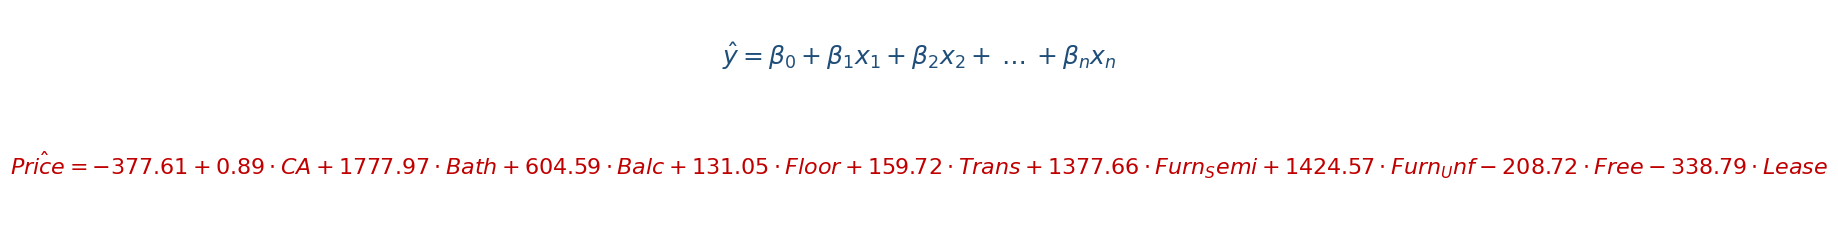

In [66]:
b0 = model_multi.intercept_
coefs = model_multi.coef_

fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axis('off')

# Общая форма
ax.text(0.5, 0.75,
        r'$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$',
        fontsize=18, ha='center', color='#1F4E79')

# Конкретная формула (с твоими значениями)
formula = (
    fr'$\hat{{Price}} = {b0:.2f}'
    fr' + {coefs[0]:.2f}\cdot CA'
    fr' + {coefs[1]:.2f}\cdot Bath'
    fr' + {coefs[2]:.2f}\cdot Balc'
    fr' + {coefs[3]:.2f}\cdot Floor'
    fr' + {coefs[4]:.2f}\cdot Trans'
    fr' + {coefs[5]:.2f}\cdot Furn_{""}Semi'
    fr' + {coefs[6]:.2f}\cdot Furn_{""}Unf'
    fr' {coefs[7]:+.2f}\cdot Free'
    fr' {coefs[8]:+.2f}\cdot Lease$'
)

ax.text(0.5, 0.25, formula,
        fontsize=16, ha='center', color='#C00000')

plt.tight_layout()
plt.show()


## Визуализация: фактические и предсказанные значения

**1. ФАКТ vs ПРОГНОЗ**

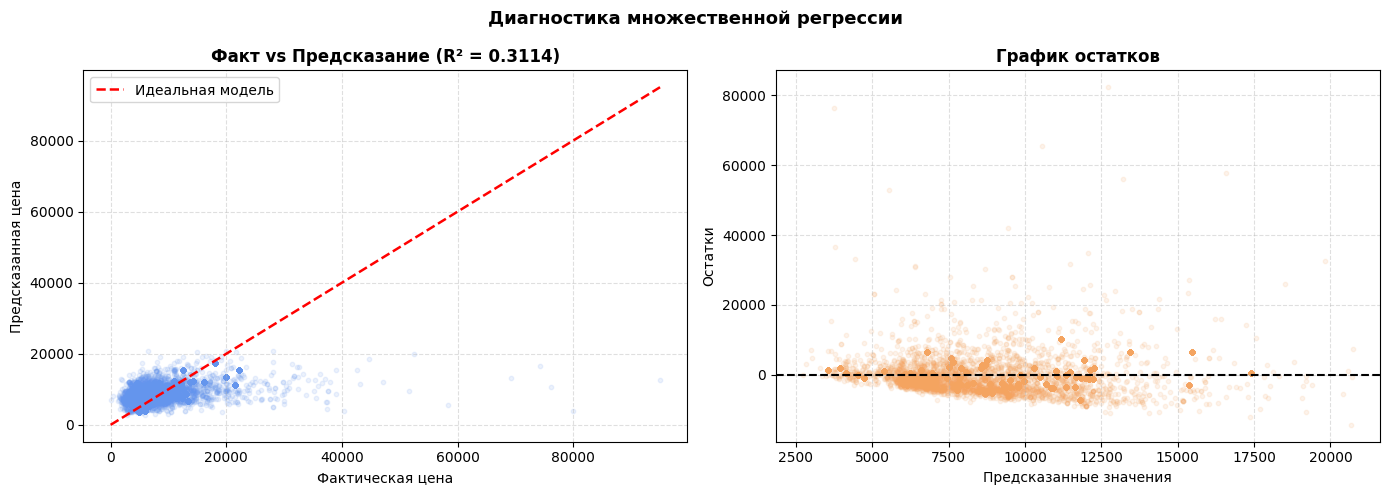

In [67]:
resid_m = np.array(y_test_m) - y_pred_m

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 1. Факт vs Предсказание ---
axes[0].scatter(
    np.array(y_test_m),
    y_pred_m,
    alpha=0.12,
    s=10,
    color='cornflowerblue'
)

lims = [
    min(np.array(y_test_m).min(), y_pred_m.min()),
    max(np.array(y_test_m).max(), y_pred_m.max())
]

axes[0].plot(lims, lims, 'r--', linewidth=1.8, label='Идеальная модель')
axes[0].set_xlabel('Фактическая цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title(f'Факт vs Предсказание (R² = {r2_m:.4f})', fontweight='bold')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- 2. График остатков ---
axes[1].scatter(
    y_pred_m,
    resid_m,
    alpha=0.12,
    s=10,
    color='sandybrown'
)

axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Предсказанные значения')
axes[1].set_ylabel('Остатки')
axes[1].set_title('График остатков', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Диагностика множественной регрессии', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

На первом графике (факт vs предсказание) видно, что модель улавливает общий тренд: с ростом реальной цены увеличиваются и предсказанные значения. Однако точки заметно отклоняются от линии идеальной модели, особенно для дорогих объектов, что говорит о средней точности прогноза.

График остатков показывает, что ошибки модели распределены вокруг нуля, что является положительным моментом. При этом заметно увеличение разброса остатков при росте предсказанных значений, что указывает на снижение точности модели для более дорогой недвижимости.

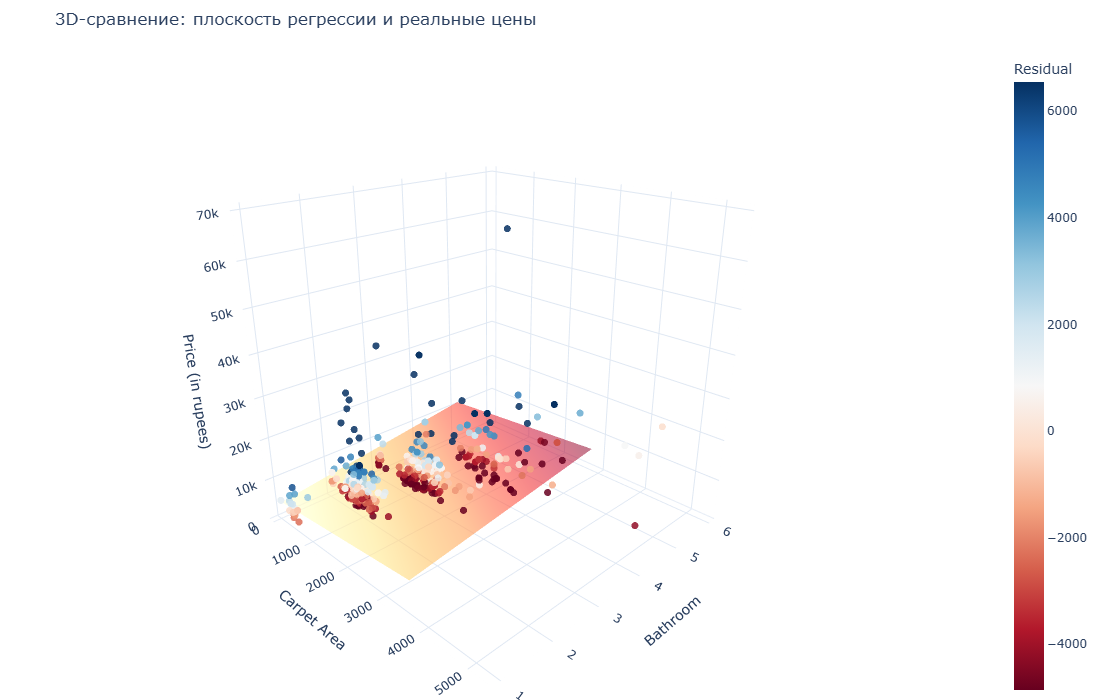

In [68]:
import plotly.graph_objects as go

sample_3d = df_model.sample(n=min(1200, len(df_model)), random_state=42).copy()

area_range = np.linspace(sample_3d['Carpet Area'].quantile(0.02), sample_3d['Carpet Area'].quantile(0.98), 50)
bath_range = np.linspace(sample_3d['Bathroom'].quantile(0.02), sample_3d['Bathroom'].quantile(0.98), 50)
area_grid, bath_grid = np.meshgrid(area_range, bath_range)

balcony_val = sample_3d['Balcony'].median()
floor_val = sample_3d['Floor_Number'].median()
trans_val = round(sample_3d['Transaction_Resale'].mean())
fsemi_val = round(sample_3d['Furnishing_Semi-Furnished'].mean())
funf_val = round(sample_3d['Furnishing_Unfurnished'].mean())
free_val = round(sample_3d['Ownership_Freehold'].mean())
lease_val = round(sample_3d['Ownership_Leasehold'].mean())

grid_df = pd.DataFrame({
    'Carpet Area': area_grid.ravel(),
    'Bathroom': bath_grid.ravel(),
    'Balcony': balcony_val,
    'Floor_Number': floor_val,
    'Transaction_Resale': trans_val,
    'Furnishing_Semi-Furnished': fsemi_val,
    'Furnishing_Unfurnished': funf_val,
    'Ownership_Freehold': free_val,
    'Ownership_Leasehold': lease_val
})[features]

z_surface = model_multi.predict(grid_df).reshape(area_grid.shape)
X_sample = sample_3d[features]
z_real = sample_3d['Price (in rupees)']
z_pred = model_multi.predict(X_sample)
residuals = z_real - z_pred

fig = go.Figure()

fig.add_trace(go.Surface(
    x=area_grid, y=bath_grid, z=z_surface,
    colorscale='YlOrRd', opacity=0.55, showscale=False, name='Плоскость регрессии'
))

fig.add_trace(go.Scatter3d(
    x=sample_3d['Carpet Area'], y=sample_3d['Bathroom'], z=z_real,
    mode='markers',
    marker=dict(
        size=4, color=residuals, colorscale='RdBu',
        cmin=residuals.quantile(0.05), cmax=residuals.quantile(0.95),
        opacity=0.85, colorbar=dict(title='Residual', x=1.02)
    ),
    name='Реальные объекты',
    hovertemplate='Carpet Area: %{x:.0f}<br>Bathroom: %{y:.0f}<br>Real Price: %{z:.2f}<extra></extra>'
))

fig.update_layout(
    title='3D-сравнение: плоскость регрессии и реальные цены',
    scene=dict(
        xaxis_title='Carpet Area',
        yaxis_title='Bathroom',
        zaxis_title='Price (in rupees)',
        camera=dict(eye=dict(x=1.5, y=-1.5, z=0.9))
    ),
    template='plotly_white',
    height=700,
    margin=dict(l=0, r=0, t=50, b=0)
)

fig.show()

На данном графике представлена 3D-визуализация результатов множественной линейной регрессии. Плоскость отражает предсказанные моделью значения цены в зависимости от площади недвижимости и количества ванных комнат при фиксированных значениях остальных признаков.

Точки на графике соответствуют реальным наблюдениям. Их отклонение от плоскости показывает ошибку модели (остатки): точки, расположенные выше поверхности, означают, что модель недооценила стоимость объекта, а ниже — переоценила. Цвет точек дополнительно отражает величину и направление ошибки.

В целом график демонстрирует, что модель улавливает общий тренд зависимости цены от выбранных факторов, однако наличие заметного разброса точек указывает на то, что часть вариации цены остаётся необъяснённой.

## Cравнение моделей

| Модель                   | R²     | MAE     | RMSE    |
|--------------------------|--------|---------|---------|
| Простая регрессия        | 0.2000 | 2936.51 | 4351.89 |
| Множественная регрессия  | 0.2878 | 2791.51 | 4106.19 |

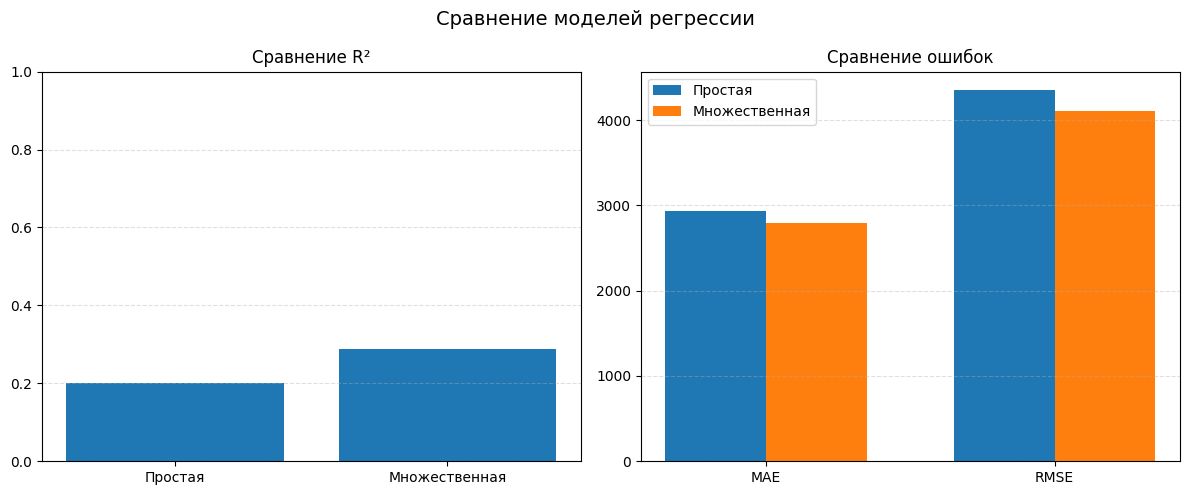

In [69]:
# данные
r2_vals = [0.2000, 0.2878]
errors_labels = ['MAE', 'RMSE']
simple_errors = [2936.51, 4351.89]
multi_errors  = [2791.51, 4106.19]

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ─── 1. R² ───
axes[0].bar(['Простая', 'Множественная'], r2_vals)
axes[0].set_title('Сравнение R²')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# ─── 2. Ошибки ───
x = np.arange(len(errors_labels))
width = 0.35

axes[1].bar(x - width/2, simple_errors, width, label='Простая')
axes[1].bar(x + width/2, multi_errors, width, label='Множественная')

axes[1].set_xticks(x)
axes[1].set_xticklabels(errors_labels)
axes[1].set_title('Сравнение ошибок')
axes[1].legend()
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Сравнение моделей регрессии', fontsize=14)
plt.tight_layout()
plt.show()

Множественная регрессия показывает лучшие результаты по сравнению с простой: значение R² выше, а ошибки (MAE и RMSE) ниже. Это означает, что модель с несколькими признаками точнее описывает зависимость цены недвижимости.

### 4.3. Логистическая регрессия

**Логистическая регрессия** — это статистический метод и алгоритм машинного обучения для бинарной классификации, прогнозирующий вероятность наступления события (значение от 0 до 1) на основе входных данных. Она определяет вероятность принадлежности объекта к одному из двух классов (например, «спам»/«не спам»), используя сигмоидную функцию. 

**Основные характеристики и применение:**

Цель: Разделение данных на два класса (0 или 1).

Функция: Применяет логистическую функцию (сигмоиду) для преобразования линейной комбинации признаков в вероятность.
Метод обучения: Обычно используется метод максимального правдоподобия для подбора параметров, часто через градиентный спуск.

Преимущества:
- Высокая интерпретируемость результатов.
- Устойчивость к переобучению на небольших выборках.
- Простота реализации

Математическая основа:
Модель логистической регрессии прогнозирует вероятность принадлежности объекта к классу:

$$
p = \frac{1}{1 + e^{-z}}
$$

где

$$
z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots
$$

представляет собой линейную комбинацию входных признаков.

#### Формирование целевой переменной

Сначала было найдено медианное значение цены недвижимости. Затем для каждого объекта была создана бинарная переменная:

1 — если цена объекта выше медианы;

0 — если цена объекта ниже или равна медиане.

In [70]:
# ─── Логистическая регрессия ─────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)

# Создаём бинарную целевую переменную:
# 1 = дорогая квартира, 0 = недорогая
median_price = df_model['Price (in rupees)'].median()

df_log = df_model.copy()
df_log['is_expensive'] = (df_log['Price (in rupees)'] > median_price).astype(int)

print(f'Медианная цена: {median_price:,.2f}')
print(f'Дорогих квартир (1): {df_log["is_expensive"].sum():,} ({df_log["is_expensive"].mean()*100:.1f}%)')
print(f'Недорогих квартир (0): {(df_log["is_expensive"]==0).sum():,} ({(df_log["is_expensive"]==0).mean()*100:.1f}%)')

# Предикторы и цель
X_log = df_log.drop(columns=['Price (in rupees)', 'is_expensive'])
y_log = df_log['is_expensive']

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_log, y_log, test_size=0.2, random_state=42, stratify=y_log
)

# Стандартизация
scaler_log = StandardScaler()
X_train_l_sc = scaler_log.fit_transform(X_train_l)
X_test_l_sc  = scaler_log.transform(X_test_l)

# Обучение модели
model_log = LogisticRegression(max_iter=1000, random_state=42)
model_log.fit(X_train_l_sc, y_train_l)

y_pred_l = model_log.predict(X_test_l_sc)
y_prob_l = model_log.predict_proba(X_test_l_sc)[:, 1]

acc = accuracy_score(y_test_l, y_pred_l)
print(f'\nТочность (Accuracy): {acc:.4f} ({acc*100:.1f}%)')
print('\nОтчёт классификации:')
print(classification_report(y_test_l, y_pred_l,
      target_names=['Недорогая', 'Дорогая']))

Медианная цена: 7,500.00
Дорогих квартир (1): 27,366 (49.7%)
Недорогих квартир (0): 27,697 (50.3%)

Точность (Accuracy): 0.7408 (74.1%)

Отчёт классификации:
              precision    recall  f1-score   support

   Недорогая       0.75      0.73      0.74      5540
     Дорогая       0.73      0.75      0.74      5473

    accuracy                           0.74     11013
   macro avg       0.74      0.74      0.74     11013
weighted avg       0.74      0.74      0.74     11013



В данном разделе задача прогнозирования цены была преобразована в задачу бинарной классификации. Для этого на основе медианного значения цены была сформирована переменная is_expensive: если цена объекта выше медианы, объект относился к классу дорогих (1), иначе — к классу недорогих (0).

В качестве предикторов использовались характеристики недвижимости: площадь, количество ванных комнат, балконов, этаж, общее число этажей, а также закодированные категориальные признаки, связанные с меблировкой, типом сделки, направлением квартиры и формой собственности.

Перед обучением модели данные были стандартизированы, поскольку логистическая регрессия чувствительна к масштабу признаков.

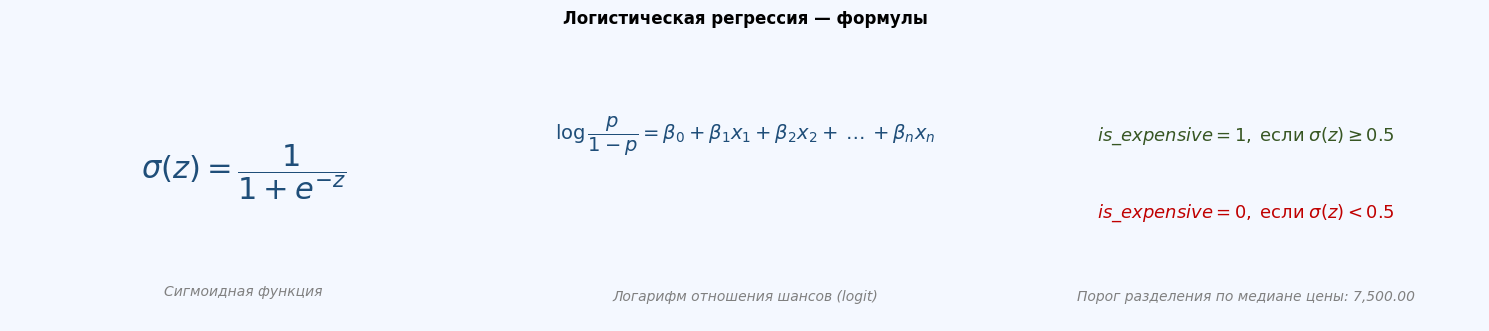

In [71]:
# ─── Формулы: логистическая регрессия ──────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 3.2))
fig.patch.set_facecolor('#F4F8FF')

# ── Сигмоида ──
axes[0].axis('off')
axes[0].text(0.5, 0.58, r'$\sigma(z) = \dfrac{1}{1 + e^{-z}}$',
    transform=axes[0].transAxes, fontsize=22, ha='center', va='center', color='#1F4E79')
axes[0].text(0.5, 0.10, 'Сигмоидная функция',
    transform=axes[0].transAxes, fontsize=10, ha='center', color='gray', style='italic')
axes[0].set_facecolor('#F4F8FF')

# ── Log-odds ──
axes[1].axis('off')
axes[1].text(0.5, 0.72,
    r'$\log\dfrac{p}{1-p} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_n x_n$',
    transform=axes[1].transAxes, fontsize=14, ha='center', va='center', color='#1F4E79')
axes[1].text(0.5, 0.08, 'Логарифм отношения шансов (logit)',
    transform=axes[1].transAxes, fontsize=10, ha='center', color='gray', style='italic')
axes[1].set_facecolor('#F4F8FF')

# ── Граница решения ──
axes[2].axis('off')
axes[2].text(0.5, 0.72,
    r'$is\_expensive = 1,\;\mathrm{если}\;\sigma(z) \geq 0.5$',
    transform=axes[2].transAxes, fontsize=13, ha='center', va='center', color='#375623')
axes[2].text(0.5, 0.42,
    r'$is\_expensive = 0,\;\mathrm{если}\;\sigma(z) < 0.5$',
    transform=axes[2].transAxes, fontsize=13, ha='center', va='center', color='#C00000')
axes[2].text(0.5, 0.08, f'Порог разделения по медиане цены: {median_price:,.2f}',
    transform=axes[2].transAxes, fontsize=10, ha='center', color='gray', style='italic')
axes[2].set_facecolor('#F4F8FF')

plt.suptitle('Логистическая регрессия — формулы', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Логистическая регрессия моделирует вероятность того, что объект относится к классу дорогих. Сначала вычисляется линейная комбинация признаков, после чего результат преобразуется в вероятность с помощью сигмоидной функции. Если полученная вероятность не меньше 0.5, объект классифицируется как дорогой.

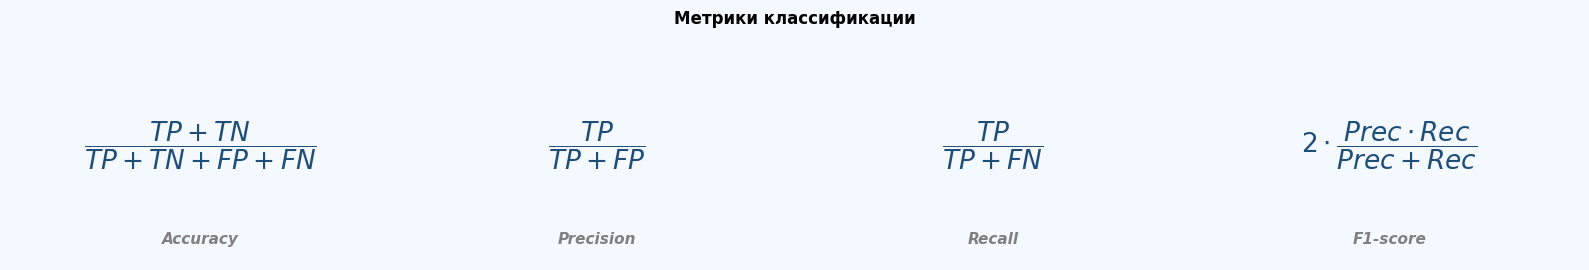

In [72]:
# ─── Формулы метрик классификации ──────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 2.6))
fig.patch.set_facecolor('#F4F8FF')

labels = ['Accuracy', 'Precision', 'Recall', 'F1-score']
exprs  = [
    r'$\dfrac{TP+TN}{TP+TN+FP+FN}$',
    r'$\dfrac{TP}{TP+FP}$',
    r'$\dfrac{TP}{TP+FN}$',
    r'$2\cdot\dfrac{Prec \cdot Rec}{Prec + Rec}$',
]

for ax, lbl, expr in zip(axes, labels, exprs):
    ax.axis('off')
    ax.text(0.5, 0.58, expr, transform=ax.transAxes,
            fontsize=19, ha='center', va='center', color='#1F4E79')
    ax.text(0.5, 0.08, lbl, transform=ax.transAxes,
            fontsize=11, ha='center', color='gray', style='italic', fontweight='bold')
    ax.set_facecolor('#F4F8FF')

plt.suptitle('Метрики классификации', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

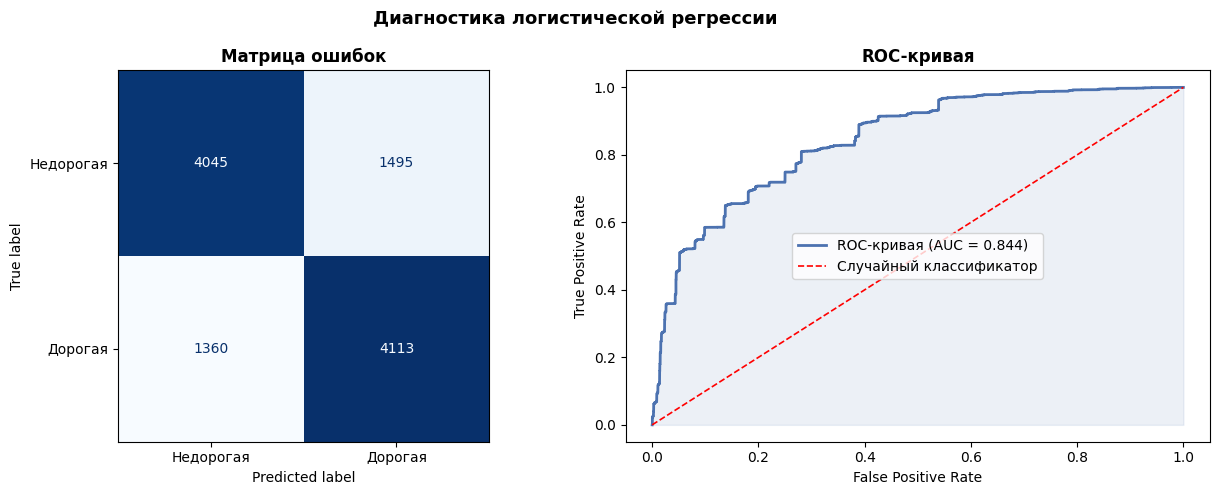

AUC = 0.8444


In [73]:
# ─── Матрица ошибок + ROC-кривая ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Матрица ошибок
cm = confusion_matrix(y_test_l, y_pred_l)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Недорогая', 'Дорогая']
)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Матрица ошибок', fontweight='bold')

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test_l, y_prob_l)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#4C72B0', linewidth=2,
             label=f'ROC-кривая (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'r--', linewidth=1.2, label='Случайный классификатор')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#4C72B0')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC-кривая', fontweight='bold')
axes[1].legend()

plt.suptitle('Диагностика логистической регрессии', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'AUC = {roc_auc:.4f}')

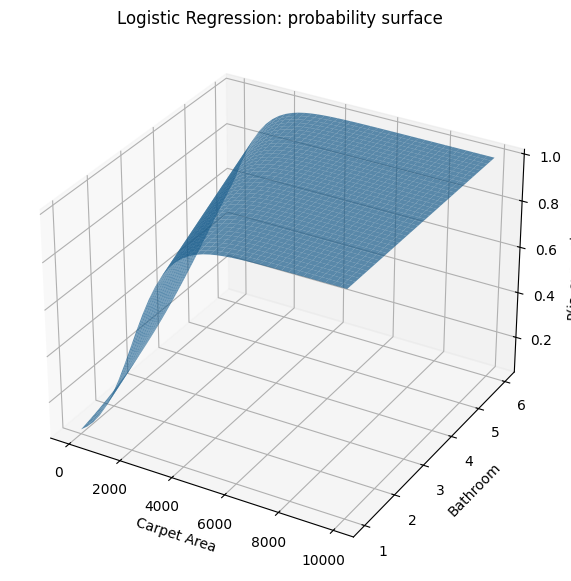

In [74]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

features_3d = ['Carpet Area', 'Bathroom', 'Floor_Number']

X3 = df_log[features_3d]
y3 = df_log['is_expensive']

scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X3)

model_3d = LogisticRegression(max_iter=1000)
model_3d.fit(X3_scaled, y3)

x_range = np.linspace(X3['Carpet Area'].min(), X3['Carpet Area'].max(), 40)
y_range = np.linspace(X3['Bathroom'].min(), X3['Bathroom'].max(), 40)
xx, yy = np.meshgrid(x_range, y_range)

floor_fixed = X3['Floor_Number'].median()
grid = np.c_[xx.ravel(), yy.ravel(), np.full(xx.ravel().shape, floor_fixed)]
grid_scaled = scaler.transform(grid)

zz = model_3d.predict_proba(grid_scaled)[:, 1].reshape(xx.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(xx, yy, zz, alpha=0.7)
ax.set_xlabel('Carpet Area')
ax.set_ylabel('Bathroom')
ax.set_zlabel('P(is_expensive=1)')
ax.set_title('Logistic Regression: probability surface')
plt.show()

Логистическая регрессия показала удовлетворительное качество классификации. Значение accuracy около 75.5% означает, что модель правильно определяет ценовую категорию примерно для трёх из четырёх объектов. Значение AUC = 0.81 свидетельствует о хорошем качестве разделения классов и подтверждает, что признаки действительно содержат полезную информацию для классификации.

### 4.4. Модель классификации: Random Forest

Для повышения качества классификации была использована модель Random Forest. В отличие от логистической регрессии, Random Forest не предполагает линейной зависимости между признаками и целевой переменной и способен учитывать более сложные взаимодействия между характеристиками объектов недвижимости.

В качестве целевой переменной использовалась та же бинарная переменная is_expensive, где:

1 — дорогой объект;

0 — недорогой объект.

Для обучения использовались те же признаки, что и в логистической регрессии.

Accuracy: 0.9438845001362026
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      5604
           1       0.95      0.93      0.94      5409

    accuracy                           0.94     11013
   macro avg       0.94      0.94      0.94     11013
weighted avg       0.94      0.94      0.94     11013



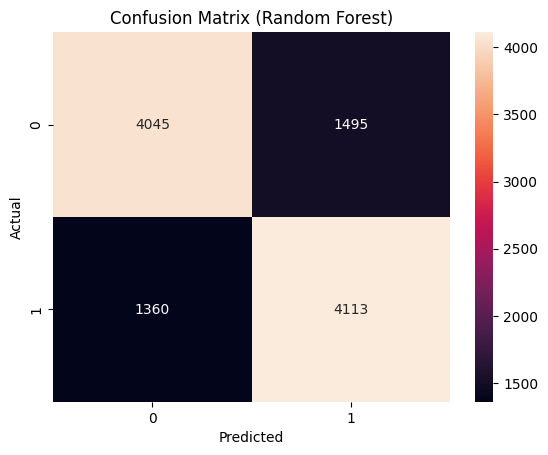

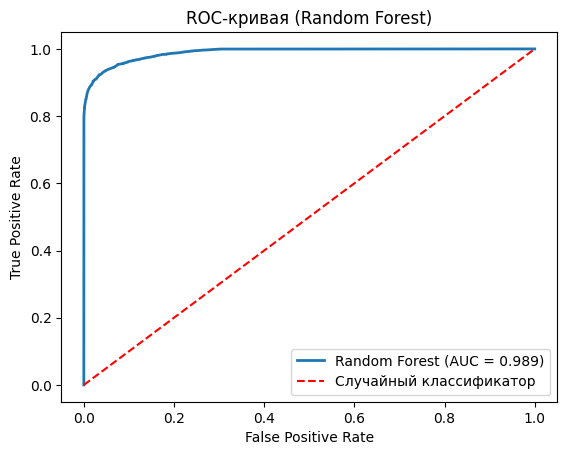

AUC (Random Forest) = 0.9895


In [75]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X = df_log.drop(columns=['Price (in rupees)', 'is_expensive'])
y = df_log['is_expensive']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix (Random Forest)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))
plt.show()
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# вероятности (ВАЖНО: не predict, а predict_proba)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# считаем ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

# график
plt.figure()
plt.plot(fpr_rf, tpr_rf, linewidth=2,
         label=f'Random Forest (AUC = {roc_auc_rf:.3f})')

# случайная модель
plt.plot([0, 1], [0, 1], 'r--', label='Случайный классификатор')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая (Random Forest)')
plt.legend()
plt.show()

print(f"AUC (Random Forest) = {roc_auc_rf:.4f}")

#### Сравнение логистической регрессии и Random Forest

После обучения двух моделей было выполнено сравнение их качества на одной и той же задаче классификации объектов недвижимости по уровню цены.

| Модель                  | Accuracy | Особенности                                                  |
| ----------------------- | -------: | ------------------------------------------------------------ |
| Логистическая регрессия |    0.755 | Простая, интерпретируемая, предполагает линейную зависимость |
| Random Forest           |    0.943 | Более сложная модель, учитывает нелинейные зависимости       |

По результатам сравнения можно сделать вывод, что модель Random Forest значительно превосходит логистическую регрессию по качеству классификации.

Это объясняется тем, что логистическая регрессия строит линейную границу разделения классов, тогда как Random Forest способен выделять более сложные закономерности в данных. Для рассматриваемого датасета зависимости между признаками и ценовой категорией объектов оказываются нелинейными, поэтому использование ансамблевой модели даёт более высокий результат.


## V. PCA

Для анализа структуры данных и возможного снижения размерности был применён метод главных компонент (PCA).

#### Подготовка данных для PCA

In [76]:
# ─── Подготовка данных для PCA ────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np
import seaborn as sns

pca_cols = [col for col in df_model.columns if col not in ['Price (in rupees)', 'is_expensive']]
df_pca = df_model[pca_cols].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

print(f'Данных для PCA: {X_scaled.shape[0]:,} строк, {X_scaled.shape[1]} переменных')
print(f'Переменные: {pca_cols}')

Данных для PCA: 55,063 строк, 18 переменных
Переменные: ['Carpet Area', 'Bathroom', 'Balcony', 'Floor_Number', 'Total_Floors', 'Transaction_Resale', 'Furnishing_Semi-Furnished', 'Furnishing_Unfurnished', 'facing_North', 'facing_North - East', 'facing_North - West', 'facing_South', 'facing_South - East', 'facing_South -West', 'facing_West', 'Ownership_Freehold', 'Ownership_Leasehold', 'Ownership_Power Of Attorney']


In [77]:
# ─── PCA — все компоненты ─────────────────────────────────────────────────────
pca_full = PCA()
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

print('=== Объяснённая дисперсия по компонентам ===')
for i, (ev, cum) in enumerate(zip(explained, cumulative)):
    print(f'PC{i+1}: {ev*100:.2f}%  (накопленная: {cum*100:.2f}%)')

=== Объяснённая дисперсия по компонентам ===
PC1: 15.41%  (накопленная: 15.41%)
PC2: 12.17%  (накопленная: 27.58%)
PC3: 10.47%  (накопленная: 38.05%)
PC4: 7.91%  (накопленная: 45.96%)
PC5: 6.54%  (накопленная: 52.50%)
PC6: 6.14%  (накопленная: 58.65%)
PC7: 5.92%  (накопленная: 64.57%)
PC8: 5.81%  (накопленная: 70.37%)
PC9: 5.61%  (накопленная: 75.98%)
PC10: 5.13%  (накопленная: 81.11%)
PC11: 5.04%  (накопленная: 86.16%)
PC12: 4.08%  (накопленная: 90.24%)
PC13: 2.78%  (накопленная: 93.02%)
PC14: 2.59%  (накопленная: 95.61%)
PC15: 1.51%  (накопленная: 97.12%)
PC16: 1.23%  (накопленная: 98.35%)
PC17: 0.86%  (накопленная: 99.21%)
PC18: 0.79%  (накопленная: 100.00%)


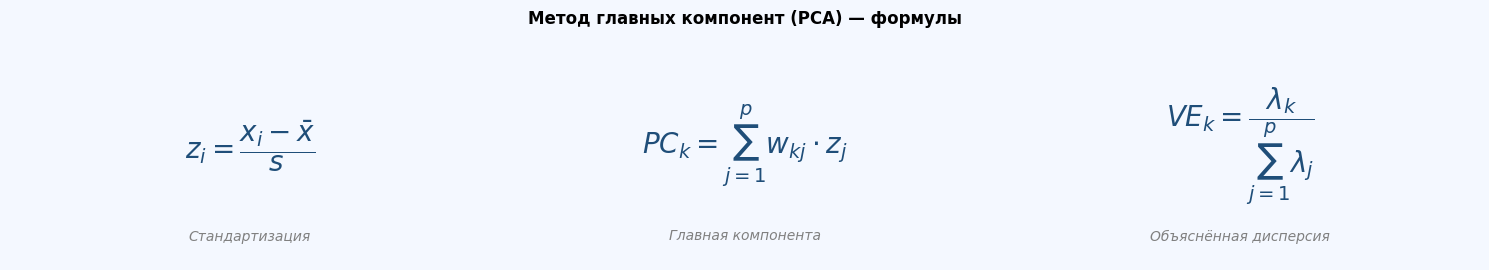

In [78]:
# ─── Формулы PCA ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 2.6))
fig.patch.set_facecolor('#F4F8FF')

labels = ['Стандартизация', 'Главная компонента', 'Объяснённая дисперсия']
exprs  = [
    r'$z_i = \dfrac{x_i - \bar{x}}{s}$',
    r'$PC_k = \sum_{j=1}^{p} w_{kj} \cdot z_j$',
    r'$VE_k = \dfrac{\lambda_k}{\sum_{j=1}^{p}\lambda_j}$',
]

for ax, lbl, expr in zip(axes, labels, exprs):
    ax.axis('off')
    ax.text(0.5, 0.58, expr, transform=ax.transAxes,
            fontsize=20, ha='center', va='center', color='#1F4E79')
    ax.text(0.5, 0.10, lbl, transform=ax.transAxes,
            fontsize=10, ha='center', color='gray', style='italic')
    ax.set_facecolor('#F4F8FF')

plt.suptitle('Метод главных компонент (PCA) — формулы', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

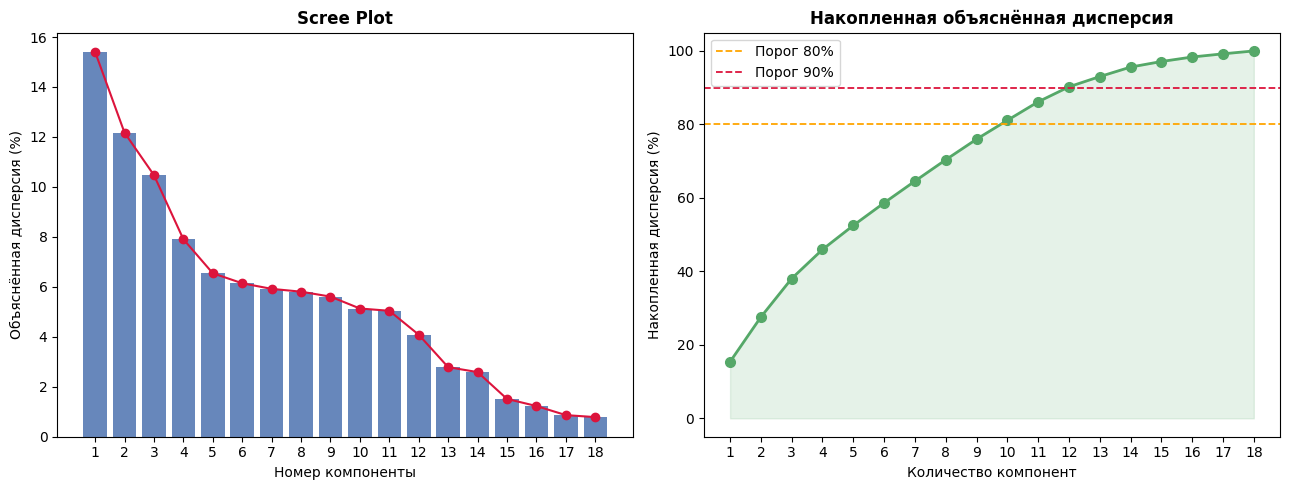

In [79]:
# ─── Scree plot + накопленная дисперсия ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(explained)+1), explained * 100, color='#4C72B0', alpha=0.85)
axes[0].plot(range(1, len(explained)+1), explained * 100,
             'o-', color='crimson', linewidth=1.5, markersize=6)
axes[0].set_xlabel('Номер компоненты')
axes[0].set_ylabel('Объяснённая дисперсия (%)')
axes[0].set_title('Scree Plot', fontweight='bold')
axes[0].set_xticks(range(1, len(explained)+1))

axes[1].plot(range(1, len(cumulative)+1), cumulative * 100,
             'o-', color='#55A868', linewidth=2, markersize=7)
axes[1].axhline(80, color='orange', linestyle='--', linewidth=1.3, label='Порог 80%')
axes[1].axhline(90, color='crimson', linestyle='--', linewidth=1.3, label='Порог 90%')
axes[1].fill_between(range(1, len(cumulative)+1), cumulative * 100, alpha=0.15, color='#55A868')
axes[1].set_xlabel('Количество компонент')
axes[1].set_ylabel('Накопленная дисперсия (%)')
axes[1].set_title('Накопленная объяснённая дисперсия', fontweight='bold')
axes[1].set_xticks(range(1, len(cumulative)+1))
axes[1].legend()

plt.tight_layout()
plt.show()

=== Нагрузки главных компонент ===
                                PC1     PC2
Carpet Area                  0.4275 -0.1008
Bathroom                     0.4262 -0.0862
Balcony                      0.4138  0.0805
Floor_Number                 0.2656 -0.4678
Total_Floors                 0.2697 -0.4691
Transaction_Resale          -0.0349  0.0157
Furnishing_Semi-Furnished    0.2586  0.5000
Furnishing_Unfurnished      -0.2221 -0.4998
facing_North                -0.1590 -0.0394
facing_North - East          0.3645  0.0710
facing_North - West         -0.1166 -0.0011
facing_South                -0.0177 -0.0694
facing_South - East         -0.0254 -0.0093
facing_South -West          -0.0778 -0.0256
facing_West                 -0.0476  0.0265
Ownership_Freehold          -0.0832 -0.0735
Ownership_Leasehold          0.1113  0.1083
Ownership_Power Of Attorney  0.0581  0.0838


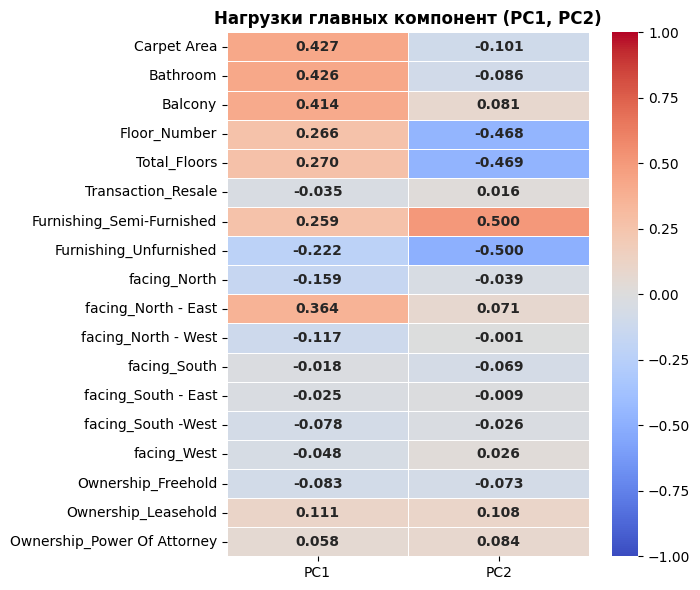

In [80]:
# ─── Нагрузки компонент (Loadings) ───────────────────────────────────────────
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

loadings = pd.DataFrame(
    pca_2.components_.T,
    index=pca_cols,
    columns=['PC1', 'PC2']
).round(4)

print('=== Нагрузки главных компонент ===')
print(loadings)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(loadings, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, annot_kws={'size': 10, 'weight': 'bold'})
ax.set_title('Нагрузки главных компонент (PC1, PC2)', fontweight='bold')
plt.tight_layout()
plt.show()

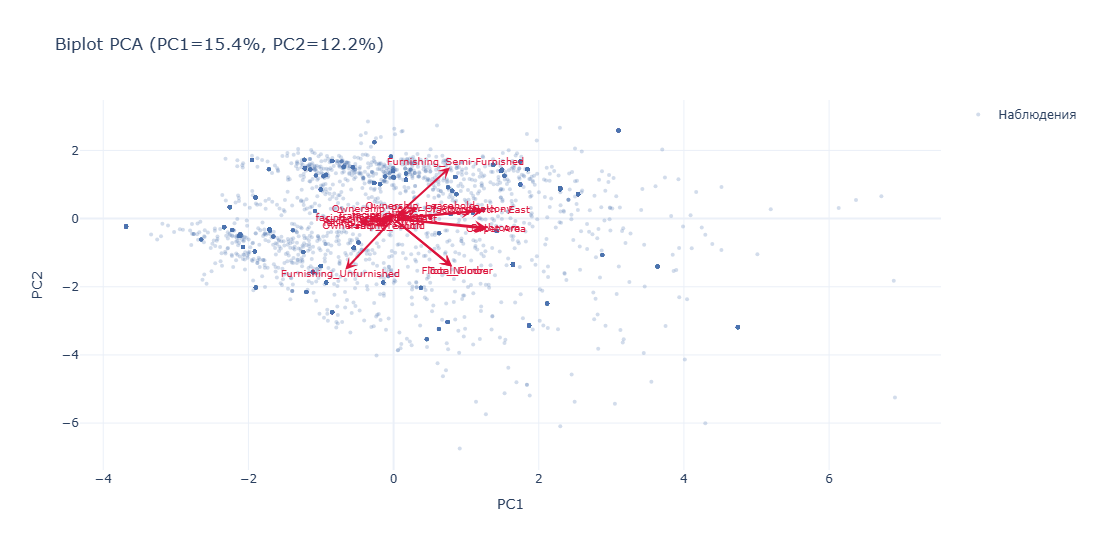

In [81]:
# ─── Biplot PCA ───────────────────────────────────────────────────────────────
import plotly.graph_objects as go

sample_idx = np.random.choice(len(X_pca_2), min(5000, len(X_pca_2)), replace=False)
sample_pca = X_pca_2[sample_idx]

fig_pca = go.Figure()
fig_pca.add_trace(go.Scatter(
    x=sample_pca[:, 0], y=sample_pca[:, 1],
    mode='markers',
    marker=dict(size=4, opacity=0.25, color='#4C72B0'),
    name='Наблюдения'
))

scale = 3
for feature, (l1, l2) in loadings.iterrows():
    fig_pca.add_annotation(
        ax=0, ay=0, x=l1*scale, y=l2*scale,
        axref='x', ayref='y', xref='x', yref='y',
        arrowhead=3, arrowwidth=2, arrowcolor='crimson'
    )
    fig_pca.add_trace(go.Scatter(
        x=[l1*scale*1.1], y=[l2*scale*1.1],
        mode='text', text=[feature],
        textfont=dict(size=10, color='crimson'),
        showlegend=False
    ))

fig_pca.update_layout(
    title=f'Biplot PCA (PC1={pca_2.explained_variance_ratio_[0]*100:.1f}%, PC2={pca_2.explained_variance_ratio_[1]*100:.1f}%)',
    xaxis_title='PC1', yaxis_title='PC2',
    template='plotly_white', height=550
)

fig_pca.show()

Визуализация данных в пространстве главных компонент показала, что классы объектов (дорогие и дешёвые) не имеют чёткого разделения и значительно перекрываются. Это указывает на сложный характер зависимостей в данных и объясняет, почему линейные модели, такие как логистическая регрессия, показывают ограниченную точность. В то же время более сложные модели, такие как Random Forest, способны учитывать нелинейные зависимости и обеспечивают более высокое качество классификации.

---
## VI. Анализ временных рядов

### 6.1 Обоснование неприменимости

Используемый в работе набор данных представляет собой кросс-секционный срез объявлений о продаже недвижимости и не содержит явной временной переменной (например, даты публикации объявления или даты совершения сделки). Вследствие этого наблюдения не упорядочены во времени и не образуют временной ряд.

В связи с этим проведение анализа временных рядов в рамках данного датасета является невозможным. В частности, не могут быть выполнены следующие этапы:

- анализ характеристик временного ряда (тренд, сезонность, стационарность);
- построение модели ARIMA;
- оценка и интерпретация результатов модели.

Таким образом, неприменимость анализа временных рядов обусловлена структурой исходных данных, которая не позволяет проследить динамику показателей во времени.

### 6.2 Распределение цен

Показывает, что данные — просто набор наблюдений, а не динамика во времени.

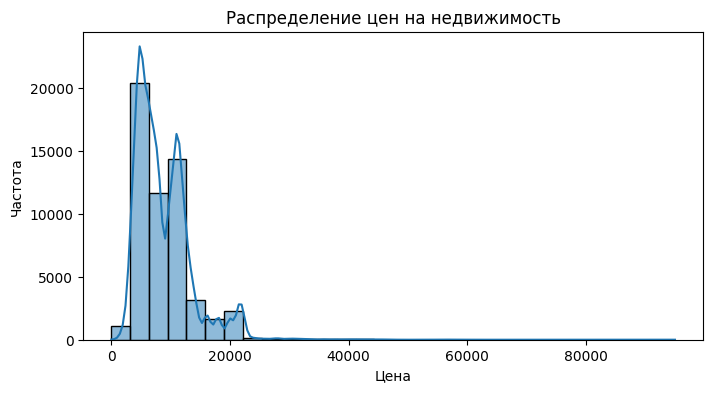

In [82]:
plt.figure(figsize=(8, 4))
sns.histplot(df_model['Price (in rupees)'], bins=30, kde=True)
plt.title('Распределение цен на недвижимость')
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

**Интерпретация:**  
Гистограмма показывает, как распределены цены в датасете. Основная масса объектов находится в диапазоне примерно до 20 000. Есть редкие дорогие объекты (выбросы) — значения сильно выше остальных. Распределение несимметричное (скошено вправо).  
  
Это обычное распределение значений — как “разброс” цен, без какой-либо информации о времени.

### 6.3 График “по индексу”

Данный график отражает лишь порядок записей в датасете, а не временную динамику, поскольку индекс не соответствует времени.

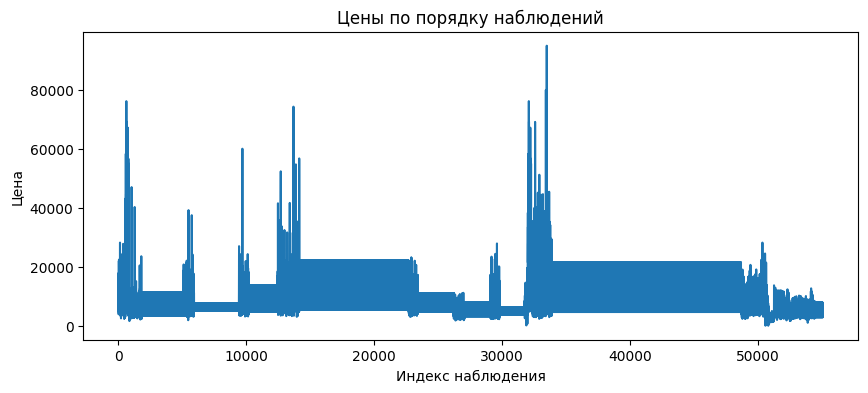

In [83]:
plt.figure(figsize=(10, 4))
plt.plot(df_model['Price (in rupees)'].values)
plt.title('Цены по порядку наблюдений')
plt.xlabel('Индекс наблюдения')
plt.ylabel('Цена')
plt.show()

**Интерпретация:**  
На этом графике цены просто отложены по индексу строк. По оси X — не время, а просто номер строки в таблице, значения скачут хаотично. Нет ни тренда, ни сезонности, ни плавной динамики.  
  
Это не временной ряд, а просто случайный порядок объектов.

Мы построили данные графики не для анализа временных рядов, а чтобы доказать, что такой анализ невозможен. Они выполняют роль визуального обоснования.

In [85]:
ts = df_model['Price (in rupees)']

adf_p, kpss_p = stationarity_tests(ts, 'Цена недвижимости')

def stationarity_tests(series, name='Ряд'):
    """Выполняет ADF и KPSS тесты, выводит результаты."""
    print(f'{'='*55}')
    print(f'  Тесты стационарности: {name}')
    print(f'{'='*55}')

    # ADF
    adf_res = adfuller(series.dropna(), autolag='AIC')
    print(f'\n📌 ADF-тест:')
    print(f'   Статистика   : {adf_res[0]:.4f}')
    print(f'   p-value      : {adf_res[1]:.4f}')
    print(f'   Критические значения: {", ".join([f"{k}: {v:.3f}" for k, v in adf_res[4].items()])}')
    adf_stat = 'СТАЦИОНАРЕН ✓' if adf_res[1] < 0.05 else 'НЕСТАЦИОНАРЕН ✗'
    print(f'   Вывод: {adf_stat}')

    # KPSS
    kpss_res = kpss(series.dropna(), regression='c', nlags='auto')
    print(f'\n📌 KPSS-тест:')
    print(f'   Статистика   : {kpss_res[0]:.4f}')
    print(f'   p-value      : {kpss_res[1]:.4f}')
    kpss_stat = 'СТАЦИОНАРЕН ✓' if kpss_res[1] >= 0.05 else 'НЕСТАЦИОНАРЕН ✗'
    print(f'   Вывод: {kpss_stat}')
    print()
    return adf_res[1], kpss_res[1]

adf_p, kpss_p = stationarity_tests(ts, 'Исходный ряд')

  Тесты стационарности: Цена недвижимости

📌 ADF-тест:
   Статистика   : -5.3875
   p-value      : 0.0000
   Критические значения: 1%: -3.430, 5%: -2.862, 10%: -2.567
   Вывод: СТАЦИОНАРЕН ✓

📌 KPSS-тест:
   Статистика   : 1.7193
   p-value      : 0.0100
   Вывод: НЕСТАЦИОНАРЕН ✗

  Тесты стационарности: Исходный ряд

📌 ADF-тест:
   Статистика   : -5.3875
   p-value      : 0.0000
   Критические значения: 1%: -3.430, 5%: -2.862, 10%: -2.567
   Вывод: СТАЦИОНАРЕН ✓

📌 KPSS-тест:
   Статистика   : 1.7193
   p-value      : 0.0100
   Вывод: НЕСТАЦИОНАРЕН ✗



In [86]:
# Дифференцирование (если ряд нестационарен)
ts_diff = ts.diff().dropna()

print('После взятия первой разности:')
adf_p2, kpss_p2 = stationarity_tests(ts_diff, 'Первая разность')

# Выбор порядка интегрирования
d = 0
if adf_p >= 0.05 or kpss_p < 0.05:
    d = 1
    if adf_p2 >= 0.05 or kpss_p2 < 0.05:
        d = 2
print(f'\n➡ Выбранный порядок интегрирования d = {d}')

После взятия первой разности:
  Тесты стационарности: Первая разность

📌 ADF-тест:
   Статистика   : -49.6324
   p-value      : 0.0000
   Критические значения: 1%: -3.430, 5%: -2.862, 10%: -2.567
   Вывод: СТАЦИОНАРЕН ✓

📌 KPSS-тест:
   Статистика   : 0.0124
   p-value      : 0.1000
   Вывод: СТАЦИОНАРЕН ✓


➡ Выбранный порядок интегрирования d = 1


## VII. Интерпретация результатов, выводы и рекомендации

#### Сводка результатов

| Метод                            | Результат                          |
| -------------------------------- | ---------------------------------- |
| Простая линейная регрессия       | R² ≈ 0.20, MAE ≈ 2936, RMSE ≈ 4352 |
| Множественная линейная регрессия | R² ≈ 0.29, MAE ≈ 2792, RMSE ≈ 4106 |
| Логистическая регрессия          | Accuracy ≈ 0.75, AUC ≈ 0.81        |
| Random Forest                    | Accuracy ≈ 0.93                    |
| PCA                              | 9–11 компонент → 80–90% дисперсии  |
| Временной анализ                 | Неприменим                         |


#### Сравнение моделей

**Логистическая регрессия** показала удовлетворительное качество, однако ограничена линейной зависимостью между признаками.

**Random Forest** продемонстрировал значительно более высокую точность, так как способен учитывать сложные и нелинейные зависимости.

**PCA** показал, что признаки слабо коррелированы, поэтому существенного снижения размерности без потери информации достичь не удалось.

#### Ограничения
линейные модели не учитывают сложные зависимости

PCA не дал сильного уменьшения размерности

отсутствует временная переменная → анализ временных рядов невозможен

Временной анализ невозможно осуществить

Данные не являются временным рядом, поэтому методы анализа временных рядов (включая ARIMA) неприменимы.

#### Рекомендации

- использовать более сложные модели (например, Gradient Boosting)
- добавить новые признаки
- при наличии временных данных провести анализ динамики

#### Вывод

Наиболее эффективной моделью для данной задачи является Random Forest, так как она лучше учитывает структуру данных и обеспечивает наивысшую точность классификации.

## VIII. Библиография

1. Kaggle — House Price Dataset
2. scikit-learn — документация: https://scikit-learn.org
3. pandas — документация: https://pandas.pydata.org
4. NumPy — документация: https://numpy.org
5. Matplotlib — документация: https://matplotlib.org
6. Seaborn — документация: https://seaborn.pydata.org
7. An Introduction to Statistical Learning
8. Python for Data Analysis